In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import barnaba as bb

In [2]:
BME_DIR = "bme_reweight"
tag = "hcp_rdc_3j_theta=16"
weights = np.load(f"{BME_DIR}/crossvals/crossval_{tag}/weights_results.npy")[0]
weights = weights.T
sub = "random_noReplace" #indicator which subensemble should be used
rdc_calc = np.loadtxt(f'calc_data/calc_rdc_loop_bme.dat')[:,1:]
w0 = np.full(rdc_calc.shape[0], 1/rdc_calc.shape[0]) # sample weights

# Plot Weight Figure
Shows distribution of weighting of frames

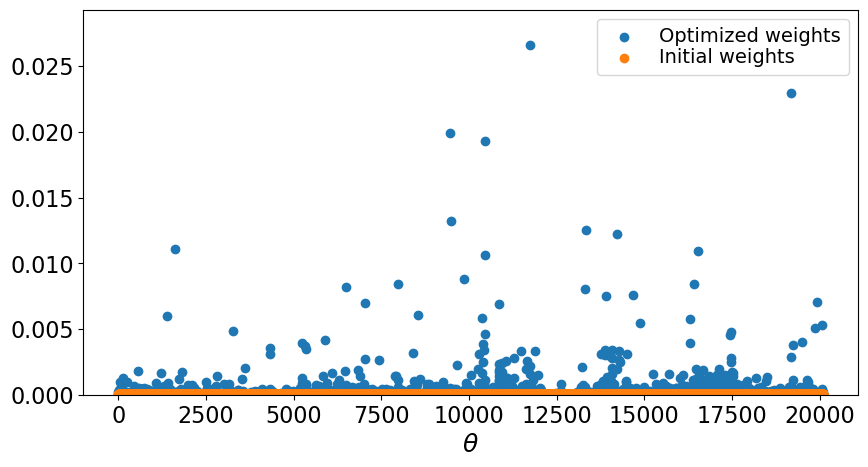

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
# load reweighted weights
w_new = weights


plt.scatter(range(len(w_new)),w_new,label="Optimized weights")
plt.scatter(range(len(w0)),w0,label="Initial weights")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,max(w_new)+max(w_new)/10)
plt.xlabel(r'$\theta$', fontsize=18)
plt.legend(fontsize=14, labelspacing=0.1)
plt.savefig(f"plots/weight_old_new_{tag}.pdf", facecolor='w')
plt.savefig(f"plots/weight_old_new_{tag}.png", facecolor='w')
plt.show()
plt.close()

## Add subsample frame marking

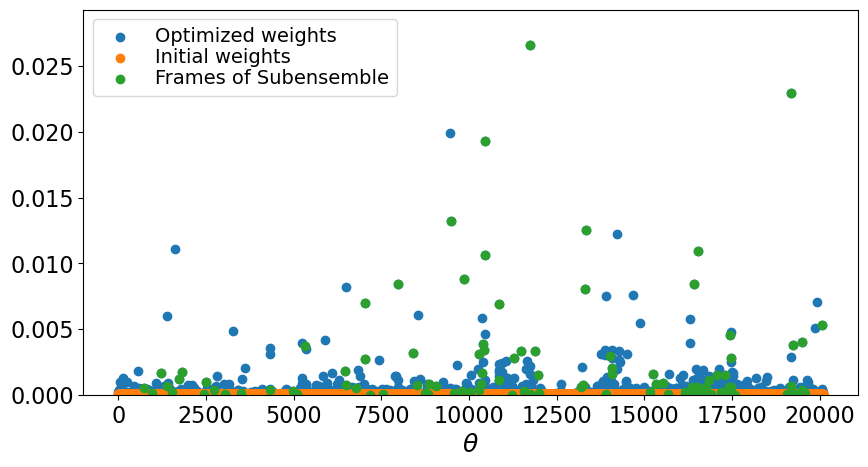

In [4]:
frames = np.load(f"qt_clustering_100/{tag}/subsampled_frames_{sub}.npy")

fig, ax = plt.subplots(figsize=(10, 5))

plt.scatter(range(len(w_new)),w_new,label="Optimized weights")
plt.scatter(range(len(w0)),w0,label="Initial weights")
plt.scatter(frames,w_new[frames],label="Frames of Subensemble")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,max(w_new)+max(w_new)/10)
plt.xlabel(r'$\theta$', fontsize=18)
plt.legend(fontsize=14, labelspacing=0.1)
plt.savefig(f"plots/weight_score_all_{tag}_{sub}.pdf", facecolor='w')  # check name of savefile
plt.savefig(f"plots/weight_score_all_{tag}_{sub}.png", facecolor='w')  # check name of savefile
plt.show()
plt.close()

## Plot Cluster Weight Distribution

In [5]:
# Load Clusters
cut = "cutoff_0_9"
cluster_array = np.loadtxt(f"qt_clustering_100/{tag}/QT_Clusters_{sub}_{cut}_minsize5.txt")
cluster_dict = {}
for cluster_id in set(cluster_array):
    cluster_dict[int(cluster_id)] = np.where(cluster_array==cluster_id)[0]
print(cluster_dict)

{0: array([ 3,  4,  6,  8, 14, 16, 22, 28, 36, 38, 42, 44, 47, 49, 52, 57, 66,
       67, 70, 74, 77, 85, 87, 91], dtype=int64), 1: array([13, 25, 27, 31, 39, 46, 48, 56, 58, 64, 68, 80], dtype=int64), 2: array([ 1, 20, 21, 29, 40, 41, 75, 76, 84, 89, 90], dtype=int64), 3: array([ 0,  5, 12, 43, 50, 51, 63, 78, 86, 98], dtype=int64), 4: array([10, 17, 34, 55, 60, 65, 83, 95, 99], dtype=int64), 5: array([ 9, 11, 15, 69, 73, 97], dtype=int64), 6: array([23, 32, 61, 93, 94], dtype=int64), -1: array([ 2,  7, 18, 19, 24, 26, 30, 33, 35, 37, 45, 53, 54, 59, 62, 71, 72,
       79, 81, 82, 88, 92, 96], dtype=int64)}


In [6]:
# load frames
frames = np.load(f"qt_clustering_100/{tag}/subsampled_frames_{sub}.npy")
frames_dict = {}
for cluster_id in set(cluster_array):
    id = cluster_dict[cluster_id]
    frames_dict[int(cluster_id)] = frames[id]
print(frames_dict)

{0: array([ 7022,   948,  6501, 19497,  4966,  7542,  2502,  7044,  7984,
        2717,  8847, 13239, 19082, 19345,  8817, 19499, 13304,  3500,
       13333,  1810,  7174,  6775, 19337,  8410]), 1: array([16371, 16650, 16529, 16894, 16752, 16430, 16318, 16836, 17079,
       16448, 16163, 16497]), 2: array([11985, 11753, 11889, 11237, 15261, 11960, 15532, 15687, 11282,
       15172, 15326]), 3: array([ 9051,  9856, 10453, 10389, 10458, 10298, 10288,  9473, 10380,
       10331]), 4: array([17475, 17314, 17455, 17479, 17453, 17188, 17427, 17473, 17581]), 5: array([19175, 19231, 19194,  5323,  5098,  3036]), 6: array([ 740, 2428, 4319, 1740, 6463]), -1: array([10016, 13921, 11731, 14075, 14072,  9570,  9771, 13196,  8747,
       19573, 19156,  1390,  9807, 10442, 10867, 20084, 10858, 14031,
        1206,  8530, 11496, 11569,  1533])}


### Calculate Cluster Weight Distribution

In [7]:
sum_all = 0
cluster_weights = {}
for i in frames_dict.keys():
    cluster_weights[i] = []
    for w in weights[frames_dict[i]]:
        cluster_weights[i].append(w)
    sum_all += np.sum(cluster_weights[i])

print(sum_all)

clu_list = []
clu_p_list = []
for i in frames_dict: 
    clu_list.append(i)
    clu_w = cluster_weights[i]
    clu_p = (np.sum(clu_w)/sum_all)*100
    clu_p_list.append(clu_p)
    print("Cluster", i, "weighting in %:", clu_p)
shares = np.column_stack((clu_list, clu_p_list))
# pd.DataFrame(shares).to_csv(f'plots/cluster_shares_{clustering}_{cutoff}.txt', sep='\t', index=False, header=['Cluster', 'Percentage of weight'])

0.25496778679113763
Cluster 0 weighting in %: 20.762728470454967
Cluster 1 weighting in %: 9.461855845806426
Cluster 2 weighting in %: 14.891339645419102
Cluster 3 weighting in %: 24.471207689581288
Cluster 4 weighting in %: 4.171136557660005
Cluster 5 weighting in %: 12.252585501665077
Cluster 6 weighting in %: 1.541670624952126
Cluster -1 weighting in %: 12.447475664461006


In [8]:
# Load Clusters
cluster_array = np.loadtxt(f"qt_clustering_100/{tag}/QT_Clusters_{sub}_{cut}_minsize5.txt")
cluster_dict = {}
for cluster_id in set(cluster_array):
    cluster_dict[int(cluster_id)] = np.where(cluster_array==cluster_id)[0]
print(cluster_dict)

{0: array([ 3,  4,  6,  8, 14, 16, 22, 28, 36, 38, 42, 44, 47, 49, 52, 57, 66,
       67, 70, 74, 77, 85, 87, 91], dtype=int64), 1: array([13, 25, 27, 31, 39, 46, 48, 56, 58, 64, 68, 80], dtype=int64), 2: array([ 1, 20, 21, 29, 40, 41, 75, 76, 84, 89, 90], dtype=int64), 3: array([ 0,  5, 12, 43, 50, 51, 63, 78, 86, 98], dtype=int64), 4: array([10, 17, 34, 55, 60, 65, 83, 95, 99], dtype=int64), 5: array([ 9, 11, 15, 69, 73, 97], dtype=int64), 6: array([23, 32, 61, 93, 94], dtype=int64), -1: array([ 2,  7, 18, 19, 24, 26, 30, 33, 35, 37, 45, 53, 54, 59, 62, 71, 72,
       79, 81, 82, 88, 92, 96], dtype=int64)}


cluster 0 [ 3  4  6  8 14 16 22 28 36 38 42 44 47 49 52 57 66 67 70 74 77 85 87 91], 20.762728470454967
cluster 1 [13 25 27 31 39 46 48 56 58 64 68 80], 9.461855845806426
cluster 2 [ 1 20 21 29 40 41 75 76 84 89 90], 14.891339645419102
cluster 3 [ 0  5 12 43 50 51 63 78 86 98], 24.471207689581288
cluster 4 [10 17 34 55 60 65 83 95 99], 4.171136557660005
cluster 5 [ 9 11 15 69 73 97], 12.252585501665077
cluster 6 [23 32 61 93 94], 1.541670624952126
cluster -1 [ 2  7 18 19 24 26 30 33 35 37 45 53 54 59 62 71 72 79 81 82 88 92 96], 12.447475664461006


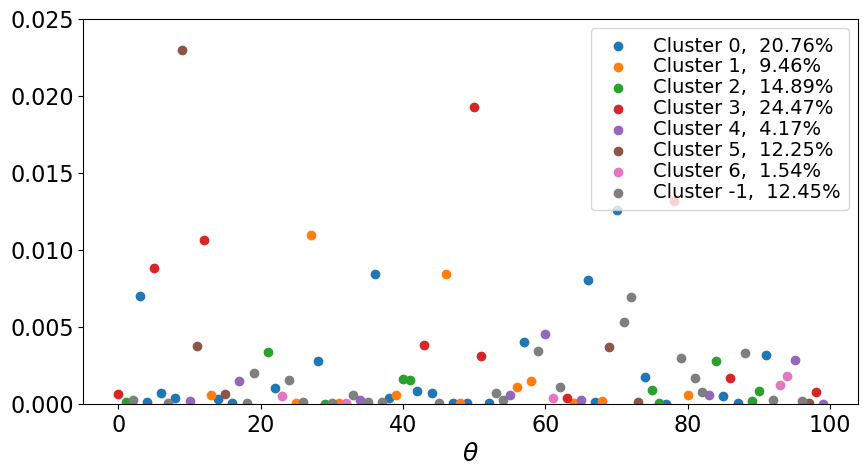

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
max_w = 0
for i in cluster_dict.keys():
    clu_w = cluster_weights[i]
    clu_f = cluster_dict[i] 
    clu_p = (np.sum(clu_w)/sum_all)*100
    print(f"cluster {i} {clu_f}, {clu_p}")
    if np.sum(clu_w) > max_w:
        max_w = np.max(clu_w)
    
    plt.scatter(clu_f,clu_w,label=f"Cluster {i},  {round(clu_p, 2)}%")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0,0.025) #max_w +(max_w/10)
plt.xlabel(r'$\theta$', fontsize=18)
plt.legend(fontsize=14, labelspacing=0.1)
plt.savefig(f"plots/weight_score_{tag}_{sub}_{cut}.pdf", facecolor='w')
plt.savefig(f"plots/weight_score_{tag}_{sub}_{cut}.png", facecolor='w')
plt.show()
plt.close()

### get weightings of unclustered but highly weighted frames

In [10]:
# get frame id:
# in this case last two frames of subensemble, only makes sense, when top100 was used, as it relies on the list of top100 weighted frames
unclu = []
for i in [-1, -2, -3, -4]: # define which frames are of interest
    unclu.append(frames[i])
    print(f"frame {i}:", frames[i])

print("Frame, weighting, share of subensemble")
for frame in unclu:
    w_unclu = w_new[frame]
    anteil = (w_unclu/sum_all)*100
    print(frame, w_unclu, anteil)

frame -1: 17581
frame -2: 10331
frame -3: 3036
frame -4: 1533
Frame, weighting, share of subensemble
17581 6.345533703868885e-06 0.002488758985489789
10331 0.0007859509996942895 0.30825501903035235
3036 7.820165756807216e-05 0.03067119127175573
1533 0.0001693608003752462 0.06642439129535284


In [11]:
print("Frame in MD, Frame in Subensemble, weighting, share of subensemble, cluster")
high_frame = []
for i in frames:
    if w_new[i] > 0.005:
        pop = (w_new[i]/sum_all)*100
        clu_ind = cluster_array[frames.tolist().index(i)]
        if clu_ind == -1.0:
            print(i, (frames.tolist().index(i))+1, w_new[i], pop, clu_ind)
    

Frame in MD, Frame in Subensemble, weighting, share of subensemble, cluster
20084 72 0.005302727782454514 2.0797638200461606 -1.0
10858 73 0.006935768587221476 2.720252889398558 -1.0


# Calculate RMSE and $\chi^2$ comparing Experimental and (Reweighted) Calculated Data 

## Load Experimental, Calculated and Bundle Data

In [12]:

bundles = ["1_3", "2_2", "1ZIH", "Farfar1", "Farfar2", "alphafold3"]

# labels
hcch_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcch_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
hcn_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcn_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
hcp_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcp_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
noe_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_noe_loop_bme.dat", delim_whitespace=True, usecols=[0])['#'])
j3_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_j3_bme.dat", delim_whitespace=True, usecols=[0]).index)
rdc_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_rdc_bme.dat", delim_whitespace=True, usecols=[0]).index)


# Experimental
rdc_exp = np.loadtxt(f"{BME_DIR}/exp_rdc_bme.dat",usecols=[1,2])
hcch_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcch_loop_bme.dat",usecols=[1,2])
hcn_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcn_loop_bme.dat",usecols=[1,2])
hcp_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcp_loop_bme.dat",usecols=[1,2])
noe_exp = np.loadtxt(f"{BME_DIR}/exp_noe_loop_bme.dat",usecols=[1,2])
j3_exp = np.loadtxt(f"{BME_DIR}/exp_j3_bme.dat",usecols=[1,2])

## Experimental for PDB structure 1ZIH, which has different stem needs to be fitted with only loop rdcs
rdc_1ZIH_exp = np.loadtxt(f"{BME_DIR}/exp_rdc_loop_bme.dat",usecols=[1,2])

# Calculated
rdc_calc = np.loadtxt(f"{BME_DIR}/calc_rdc_bme.dat")[:,1:]
hcch_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcch_loop_bme.dat")[:,1:]
hcn_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcn_loop_bme.dat")[:,1:]
hcp_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcp_loop_bme.dat")[:,1:]
noe_calc = np.loadtxt(f"{BME_DIR}/calc_noe_loop_bme.dat")[:,1:]
j3_calc = np.loadtxt(f"{BME_DIR}/calc_j3_bme.dat")[:,1:]

# Bundles
j3_bundles = {}
noe_bundles = {}
hcch_bundles = {}
hcn_bundles = {}
hcp_bundles = {}
rdc_bundles = {}
L_bundles = {}

for b in bundles:
    j3_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_j3_loop_bme.dat')[:,1:]
    if b == "1ZIH":
        rdc_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_rdc_loop_bme.dat')[:,1:]
    else:
        rdc_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_rdc_all_bme.dat')[:,1:]
    hcch_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_ccr_calc_HCCH_loop_bme.dat')[:,1:]
    hcn_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_ccr_calc_HCN_loop_bme.dat')[:,1:]
    hcp_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_ccr_calc_HCP_loop_bme.dat')[:,1:]
    noe_bundles[b] = np.loadtxt(f'nmrbundle_data/nmrbundle_{b}_dists_loop.dat')[:,1:]
    L_bundles[b] = np.load(f'nmrbundle_data/nmrbundle_{b}_rdc_all_bme_L.npy') 

# L_calc
L_calc = np.sum(rdc_exp[:,0]*np.average(rdc_calc, axis=0))/np.sum(np.average(rdc_calc, axis=0)*np.average(rdc_calc, axis=0))

# Reweighted weights
w_rew = weights

## Use RMSE Script to calc all RMSE

In [13]:
%load_ext autoreload
%autoreload 2
import os
import sys
module_path = os.path.abspath(os.path.join('lib')) # or the path to your source code
sys.path.insert(0, module_path)

In [14]:
import lib.rmse as rmse
from importlib import reload
reload(rmse)

<module 'lib.rmse' from 'z:\\14_MD_stuff\\20250630_GCAA_analysis_V5\\lib\\rmse.py'>

In [15]:
rmse_md = {}
# calc rmse for MD simulation compared to experimanetal data
rmse_md['MD'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, w0), 
                          rmse.calc_RMSE_ensemble(j3_exp, j3_calc[:,:], w0), 
                          rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], w0),
                          rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], w0),
                          rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], w0), 
                          rmse.calc_RMSE_ensemble(noe_exp, noe_calc[:,:], w0, noe=True)])

# calc rmse for reweighted MD simulation compared to experimental data
rmse_md['MD+Exp'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, w_rew[:].T), 
                              rmse.calc_RMSE_ensemble(j3_exp, j3_calc[:,:], w_rew[:]), 
                              rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], w_rew[:]), 
                              rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], w_rew[:]),
                              rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], w_rew[:]),
                              rmse.calc_RMSE_ensemble(noe_exp, noe_calc[:,:], w_rew[:], noe=True)])

w0_100 = np.array([1/100]*100)
rmse_md['Bundle MD+Exp'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[frames,:]*L_calc, w0_100), 
                                     rmse.calc_RMSE_ensemble(j3_exp, j3_calc[frames,:], w0_100), 
                                     rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[frames,:], w0_100),
                                     rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[frames,:], w0_100),
                                     rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[frames,:], w0_100), 
                                     rmse.calc_RMSE_ensemble(noe_exp, noe_calc[frames,:], w0_100, noe=True)])

In [16]:
rmse_bundles = {}
for b in bundles:
    print(b)
    if b == "1ZIH":
        rmse_bundles[b] = np.array([
            rmse.calc_RMSE_bundle(rdc_1ZIH_exp, (rdc_bundles[b][:,:].T*L_bundles[b]).T), 
            rmse.calc_RMSE_bundle(j3_exp, j3_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(hcch_exp, hcch_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcn_exp, hcn_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcp_exp, hcp_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(noe_exp, noe_bundles[b][:,:])
        ])        
    else:
        rmse_bundles[b] = np.array([
            rmse.calc_RMSE_bundle(rdc_exp, (rdc_bundles[b][:,:].T*L_bundles[b]).T),
            rmse.calc_RMSE_bundle(j3_exp, j3_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(hcch_exp, hcch_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcn_exp, hcn_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcp_exp, hcp_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(noe_exp, noe_bundles[b][:,:])
        ])

1_3
2_2
1ZIH
Farfar1
Farfar2
alphafold3


In [17]:
rmse_err = np.array([
    np.sqrt(np.average(rdc_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(j3_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcch_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcn_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcp_exp[:,1]**2, axis=-1)),
    np.power(np.average(np.power(noe_exp[:,1], -6), axis=0), -1.0 / 6)
])

In [18]:
np.power(np.average(np.power(noe_exp[:,1], -6), axis=0), -1.0 / 6)

0.6435763246808425

# Plot RMSE


RDC [Hz]
MD: 4.02 +/- 1.5
MD+Exp: 2.09 +/- 1.5
Bundle
MD+Exp: 2.22 +/- 1.5
1_3: 4.97
2_2: 4.20
1ZIH: 5.02
Farfar1: 4.50
Farfar2: 5.37
alphafold3: 4.26

3J [Hz]
MD: 2.55 +/- 1.5
MD+Exp: 2.07 +/- 1.5
Bundle
MD+Exp: 2.09 +/- 1.5
1_3: 3.15
2_2: 3.43
1ZIH: 3.30
Farfar1: 3.21
Farfar2: 3.15
alphafold3: 3.33

$\Gamma$-HCCH [Hz]
MD: 4.02 +/- 3.93
MD+Exp: 3.62 +/- 3.93
Bundle
MD+Exp: 3.71 +/- 3.93
1_3: 4.52
2_2: 8.93
1ZIH: 6.33
Farfar1: 6.37
Farfar2: 6.56
alphafold3: 5.27

$\Gamma$-HCN [Hz]
MD: 1.03 +/- 0.46
MD+Exp: 1.01 +/- 0.46
Bundle
MD+Exp: 0.93 +/- 0.46
1_3: 3.75
2_2: 5.04
1ZIH: 2.01
Farfar1: 3.32
Farfar2: 3.44
alphafold3: 1.69

$\Gamma$-HCP [Hz]
MD: 7.56 +/- 1.5
MD+Exp: 3.82 +/- 1.5
Bundle
MD+Exp: 4.30 +/- 1.5
1_3: 7.43
2_2: 8.54
1ZIH: 8.51
Farfar1: 10.54
Farfar2: 8.08
alphafold3: 8.42

NOE [$\AA$]
MD: 0.52 +/- 0.64
MD+Exp: 0.47 +/- 0.64
Bundle
MD+Exp: 0.48 +/- 0.64
1_3: 0.73
2_2: 0.78
1ZIH: 0.97
Farfar1: 0.91
Farfar2: 0.85
alphafold3: 0.86


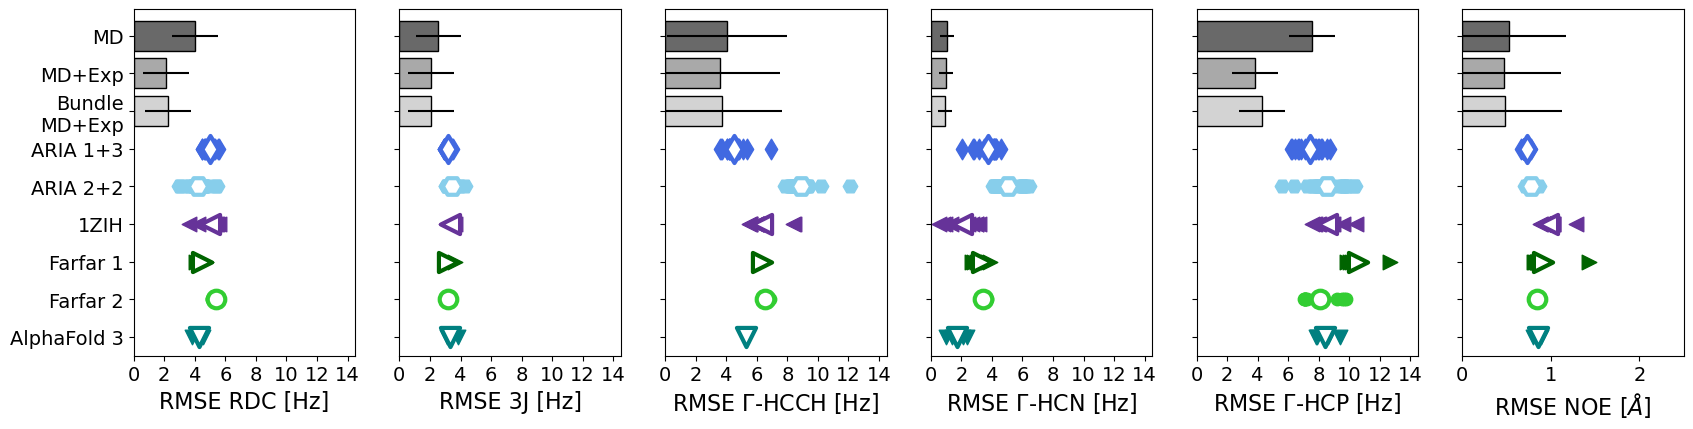

In [ ]:
bundle_labels = ["ARIA 1+3", "ARIA 2+2", "1ZIH", "Farfar 1", "Farfar 2", "AlphaFold 3"]

greys = ['dimgrey', 'darkgrey', 'lightgrey']
lbl = ['RDC [Hz]', '3J [Hz]', r'$\Gamma$-HCCH [Hz]', r'$\Gamma$-HCN [Hz]',r'$\Gamma$-HCP [Hz]', r'NOE [$\AA$]']
#b_lbl = ["ARIA" ]
x_lbl = ['MD', 'MD+Exp', 'Bundle\nMD+Exp'] + bundle_labels

lbl_dict_ = {
    # 3J:
    "C4Pb": r"$\rm ^3J(C4'_{i}\!,\!P_{i})$",
    "C4Pe": r"$\rm ^3J(C4'_{i}\!,\!P_{i\!+\!1})$",
    "1H5P": r"$\rm ^3J(H5'\!,\!P_{i})$",
    "2H5P": r"$\rm ^3J(H5''\!,\!P_{i})$",
    "1H5H4": r"$\rm ^3J(H4'\!,\!H5')$",
    "2H5H4": r"$\rm ^3J(H4'\!,\!H5'')$",
    "H1H2": r"$\rm ^3J(H1'\!,\!H2')$",
    "H2H3": r"$\rm ^3J(H2'\!,\!H3')$",
    "H3H4": r"$\rm ^3J(H3'\!,\!H4')$",
    "H3P": r"$\rm ^3J(H3'\!,\!P_{i\!+\!1})$",
    
    # CCR:
    "C1-C2": r"$\rm \Gamma^{DD\!,\!DD}_{(C1'H1'\!,\!C2'H2')}$",
    "C3-C4": r"$\rm \Gamma^{DD\!,\!DD}_{(C3'H3'\!,\!C4'H4')}$",
    "C4p-P": r"$\rm \Gamma^{DD\!,\!CSA}_{(C4'_iH4_i\!,\!P_{i})}$",
    "C3p-P-plus": r"$\rm \Gamma^{DD\!,\!CSA}_{(C3'_iH3_i\!,\!P_{i\!+\!1})}$",
    "C4p-P-plus": r"$\rm \Gamma^{DD\!,\!CSA}_{(C4'_iH4_i\!,\!P_{i\!+\!1})}$",
    "C5p-P": r"$\rm \Gamma^{DD\!,\!CSA}_{(C5'_iH5_i\!,\!P_{i})}$",
    "C1-CC": r"$\rm \Gamma^{DD\!,\!DD}_{(C6H6/C8H8\!,\!C1'H1')}$",
            }

cc = ['royalblue', 'skyblue', 'rebeccapurple', 'darkgreen', 'limegreen', 'teal'] #'#56B4E9', '#009E74', '#D55C00', '#F0E442', '#826aed', '#ff90b3', '#f7d9a7'
markers = ['d', 'H', '<', '>', 'o', 'v','D']
msizes = [110, 110, 110, 110, 80, 110, 80] # markersizes

fig, axes= plt.subplots(1,len(lbl),figsize=[20,4.5], sharey=True)


for i in range(len(lbl)):
    print(f'\n{lbl[i]:}')
    plt.subplot(1,len(lbl),i+1)
    for j,k in enumerate(rmse_md.keys()):
        if i == len(lbl):
            plt.barh(x_lbl[j], rmse_md[k][i], edgecolor='k', color=greys[j], height=0.8, xerr=np.array(rmse_md[k][i],rmse_err[i]))
        else:
            plt.barh(x_lbl[j], rmse_md[k][i], edgecolor='k', color=greys[j], height=0.8, xerr=rmse_err[i])
        print(f'{x_lbl[j]}: {rmse_md[k][i]:.2f} +/- {round(rmse_err[i],2)}')

    for j,k in enumerate(rmse_bundles.keys()):
        plt.scatter(rmse_bundles[k][i,:], [k for j in range(rmse_bundles[k].shape[-1])], marker=markers[j], color=cc[j], s=msizes[j])#, alpha=0.7)
        plt.scatter(np.average(rmse_bundles[k][i,:]), k, marker=markers[j], edgecolor=cc[j], color='w', s=msizes[j]+80, zorder=10, linewidths=3)
        print(f'{k}: {np.average(rmse_bundles[k][i,:]):.2f}')
    
    plt.yticks(range(len(x_lbl)), x_lbl, rotation=0, fontsize=14)
    plt.xticks(fontsize=14)
    plt.xlabel(f'RMSE {lbl[i]}', fontsize=16)     
    plt.ylim(-0.7,len(x_lbl)-0.5) 
    plt.gca().invert_yaxis()
    for b in range(0,(len(lbl)-1)):
        plt.sca(axes[b])
        plt.xticks([0,2,4,6,8,10,12,14])
        plt.xlim(0,14.5) 
        
    plt.sca(axes[(len(lbl)-1)])
    #plt.xticks([0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00])
    plt.xticks([0.00, 1.00, 2.00])
    plt.xlim(0,2.5)
plt.savefig(f'plots/rmse_comp_all_horiz.pdf', facecolor='white', bbox_inches='tight')
plt.savefig(f'plots/rmse_comp_all_horiz.png', facecolor='white', bbox_inches='tight')
plt.show()


# Calculate dihedral angles

In [20]:
angles_bb = ["alpha","beta","gamma","delta","eps","zeta","chi"]

Load and get angles for PDB MD:

In [21]:
traj_f   = f'gcaa_simulations/concat_traj_nopbc.xtc'
top_f    = f'gcaa_simulations/initial_nopbc_mdtraj.pdb'
gcaa_resid = ['C_5_0', 'G_6_0', 'C_7_0', 'A_8_0', 'A_9_0', 'G_10_0']

aa_md,res_md = bb.backbone_angles(traj_f, top_f, residues=gcaa_resid, angles=angles_bb)
aa_md *= 180.0/np.pi
print(aa_md.shape)

# Loading gcaa_simulations/concat_traj_nopbc.xtc 


(20100, 6, 7)


Load and get angles for bundles and 1RNG:

In [22]:
aa_bundles = {}
for b in bundles:
    aa_bundles[b] = rmse.get_angles_bundle(f'nmrbundle_data/Bundle_{b}.pdb', angles_bb,res_list=gcaa_resid)*180.0/np.pi

# Loading nmrbundle_data/Bundle_1_3.pdb 
# Skipping unknown residue URI11 


(20, 6, 7)


# Loading nmrbundle_data/Bundle_2_2.pdb 
# Skipping unknown residue URI11 


(20, 6, 7)


c:\Users\david_leopold\anaconda3\Lib\site-packages\mdtraj\formats\pdb\pdbfile.py:200: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn('Unlikely unit cell vectors detected in PDB file likely '
# Loading nmrbundle_data/Bundle_1ZIH.pdb 


(10, 6, 7)


# Loading nmrbundle_data/Bundle_Farfar1.pdb 
# Loading nmrbundle_data/Bundle_Farfar2.pdb 


(10, 6, 7)
(10, 6, 7)
(5, 6, 7)


# Loading nmrbundle_data/Bundle_alphafold3.pdb 


## Dihedrals from cluster 0 and 2

In [ ]:
def get_measurement_idx(lbl_list, res, measurement):
    lbl = f'{res}:{measurement}'
    idx = lbl_list.index(lbl)
    return idx

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx #array[idx]

def plot_angle_measurement(res, angle, measurements, mtype, save=False): 
    markers = ['d', 'H', '<', '>', 'o', 'v','D']
    msizes = [110, 110, 110, 110, 80, 110, 80] # markersizes
    
    
    if(angle=="delta"):
        bins=np.linspace(0,180,45)
        ang_add = 0
    elif(angle=="alpha" or angle == "beta" or angle == "gamma" or angle == "zeta" or angle == "eps"):
        ang_add = 360
        bins=np.linspace(0,360,90)
    else:
        bins=np.linspace(-180,180,90)

    idxs = []
    for m in measurements:
        if mtype == 'hcch':
            idxs.append(get_measurement_idx(hcch_lbl, res, m))
            data_e, data_c, data_b = hcch_exp, hcch_calc, hcch_bundles
            ylbl = 'CCR [Hz]'
        if mtype == 'hcn':
            idxs.append(get_measurement_idx(hcn_lbl, res, m))
            data_e, data_c, data_b = hcn_exp, hcn_calc, hcn_bundles
            ylbl = 'CCR [Hz]'
        if mtype == 'hcp':
            idxs.append(get_measurement_idx(hcp_lbl, res, m))
            data_e, data_c, data_b = hcp_exp, hcp_calc, hcp_bundles
            ylbl = 'CCR [Hz]'
        elif mtype == 'j3':
            idxs.append(get_measurement_idx(j3_lbl, res, m))
            data_e, data_c, data_b = j3_exp, j3_calc, j3_bundles
            ylbl = r'$\mathregular{^3J}$ [Hz]'
        else:
            print('Check measurement type!')
            break


    fig, ax = plt.subplots(2,1, figsize=[10,9])
    ###### UPPER PANEL ######
    for i,idx in enumerate(idxs):
        # Exp:
        err = ax[0].errorbar(0.8+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2., capthick=2., capsize=12, zorder=10, label='Exp') # This is just for the legend
        ax[0].errorbar(0.8+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2.5, capthick=2.5, capsize=210/len(measurements), zorder=10, label='Exp')
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True)
        ax[0].plot((hh/hh.max()*0.1*len(measurements))+(.833+i), 0.5*(ee[1:] + ee[:-1]), c='dimgrey', lw=4, zorder=8)
        ax[0].scatter(np.array((hh/hh.max()*0.1*len(measurements))+(.833+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx]))], np.average(data_c[:,idx]), marker='o', s=170, edgecolor=None, color='dimgrey', zorder=8.5)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True, weights=w_rew)
        ax[0].plot((hh/hh.max()*0.1*len(measurements))+(.833+i), 0.5*(ee[1:] + ee[:-1]), c='darkgrey', lw=4, ls='--', dashes=(2,1), zorder=9)
        ax[0].scatter(np.array((hh/hh.max()*0.1*len(measurements))+(.833+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx], weights=w_rew))], np.average(data_c[:,idx], weights=w_rew), marker='o', s=120, edgecolor=None, color='darkgrey',zorder=9.5)
        # MD+Exp bundle:
        ax[0].scatter([0.75+i]*len(frames), data_c[frames,idx], s=80, marker='o', color='lightgrey')#, alpha=0.7)
        ax[0].scatter([0.75+i], np.average(data_c[frames,idx], axis=0), s=230, marker='o', edgecolor='lightgrey', color='w', linewidths=4)
        # NMR Bundles + 1RNG:
        for b,bun in enumerate(bundles):
            ax[0].scatter([0.7+i-(0.07*b)]*len(data_b[bun]), data_b[bun][:,idx], s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)
            ax[0].scatter([0.7+i-(0.07*b)], np.average(data_b[bun][:,idx], axis=0), s=msizes[b]+110, marker=markers[b], edgecolor=cc[b], color='w', linewidths=3)

    # ax[0].set_xticks(np.arange(0.8, (0.8+i)*len(measurements)))
    ax[0].set_xticks([0.8+i for i in range(len(measurements)) ])
    ax[0].set_xticklabels([f'{res}:{lbl_dict_[m]}' for m in measurements])        
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].set_ylabel(ylbl, fontsize=20)

    ###### LOWER PANEL ######
    # MD:
    aa = aa_md[:,int(res[1:])-5,angles_bb.index(angle)]
    aa[np.where(aa<0)] += ang_add
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w0)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='dimgrey', lw=4, label='MD')
    # MD+Exp:
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w_rew)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='darkgrey', lw=4, ls='--', label='MD', dashes=(2,1))
    # MD+Exp bundle:
    ax[1].scatter(aa[frames], [-0.18/180*np.pi]*len(aa[frames]), s=80, marker='o', color='lightgrey')#, alpha=0.7)
    # NMR bundles and 1RNG:
    for b,bun in enumerate(bundles):
        aa = aa_bundles[bun][:,int(res[1:])-5,angles_bb.index(angle)]
        aa[np.where(aa<0)] += ang_add
        ax[1].scatter(aa, [(-b/4/180*np.pi)-0.4/180*np.pi]*len(aa), s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)


    ax[1].set_xticks(np.arange(0,bins.max()+1,bins.max()/4))
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    ax[1].set_xlabel(r'$\mathregular{{s1}}$ [$\degree$] '.replace('s1', '\\'+angle), fontsize=20)
    ax[1].set_ylabel('Density', fontsize=20)
    # Custom legend:
    handles1 =  [plt.Line2D([0], [0], lw=4, color='dimgrey', label='MD'),
                 plt.Line2D([0], [0], lw=4, ls='--', dashes=(2,1), color='darkgrey', label='MD+Exp'),
                 plt.Line2D([0], [0], lw=4, ls='', color='lightgrey', marker='o', markersize=8, label='Bundle MD+Exp')]
    handles2 =  [plt.Line2D([0], [0], lw=4, ls='', color=cc[i], marker=markers[i], markersize=msizes[i]/10, label=ii) for i,ii in enumerate(bundle_labels) ]
    fig.legend(handles=[item for sublist in [[err], handles1, handles2] for item in sublist], fontsize=16, ncol=4, loc='center', bbox_to_anchor=(0.53, 0.52), fancybox=True) #, edgecolor='k'

    plt.tight_layout(h_pad=10.5)
    if save == True:
        plt.savefig(f'plots/{res}_{angle}_{"_".join(measurements)}.pdf')
        # plt.savefig(f'plots/{res}_{angle}_{"_".join(measurements)}.png', dpi=300)
    plt.show()

def plot_angle_measurement_si(res, angle, measurements, mtype, save=False):
    
    if(angle=="delta"):
        bins=np.linspace(0,180,45)
        ang_add = 0
    elif(angle=="alpha" or angle == "beta" or angle == "gamma" or angle == "zeta" or angle == "eps"):
        ang_add = 360
        bins=np.linspace(0,360,90)
    else:
        bins=np.linspace(-180,180,90)

    idxs, xticks = [],[]
    for m in measurements:
        if mtype == 'ccr':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = ccr_exp, ccr_calc, ccr_bundles, ccr_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'j3':
            # idxs.append(get_measurement_idx(j3_lbl, res, m))
            data_e, data_c, data_b, data_lbl = j3_exp, j3_calc, j3_bundles, j3_lbl
            ylbl = r'$\mathregular{^3J}$ [Hz]'
        else:
            print('Check measurement type!')
            break
        if f'{res}:{m}' in data_lbl: 
            idxs.append(get_measurement_idx(data_lbl, res, m))
            # xticks.append(f'{res}:{m}')
            xticks.append(f'{res}:{lbl_dict_[m]}')
        else:
            continue

    fig, ax = plt.subplots(2,1, figsize=[10,9])
    ###### UPPER PANEL ######
    err_ = None
    for i,idx in enumerate(idxs):
        # Exp:
        err_ = ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2, capthick=2, capsize=10, zorder=10, label='Exp') # just for the legend
        ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', markersize=9, elinewidth=2.5, capthick=2.5, capsize=80, zorder=10) #capsize=210/len(measurements)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='dimgrey', lw=4, zorder=8)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx]))], np.average(data_c[:,idx]), marker='o', s=170, edgecolor=None, color='dimgrey', zorder=8.5)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True, weights=w_rew)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='darkgrey', lw=4, ls='--', dashes=(2,1), zorder=9)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx], weights=w_rew))], np.average(data_c[:,idx], weights=w_rew), marker='o', s=120, edgecolor=None, color='darkgrey',zorder=9.5)
        # MD+Exp bundle:
        ax[0].scatter([0.93+i]*len(frames), data_c[frames,idx], s=80, marker='o', color='lightgrey')#, alpha=0.7)
        ax[0].scatter([0.93+i], np.average(data_c[frames,idx], axis=0), s=230, marker='o', edgecolor='lightgrey', color='w', linewidths=4)
        # NMR Bundles + 1RNG:
        for b,bun in enumerate(bundles):
            ax[0].scatter([0.85+i-(0.08*b)]*len(data_b[bun]), data_b[bun][:,idx], s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)
            ax[0].scatter([0.85+i-(0.08*b)], np.average(data_b[bun][:,idx], axis=0), s=msizes[b]+110, marker=markers[b], edgecolor=cc[b], color='w', linewidths=3)

    ax[0].set_xlim(0.3,3.4)
    ax[0].set_xticks(np.arange(1, len(xticks)+1))
    ax[0].set_xticklabels(xticks)        
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].set_ylabel(ylbl, fontsize=20)
    ###### LOWER PANEL ######
    # MD:
    # tors[np.where(tors<0)] += 2*np.pi
    aa = aa_md[:,int(res[1:])-5,angles_bb.index(angle)]
    aa[np.where(aa<0)] += ang_add
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w0)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='dimgrey', lw=4, label='MD')
    # MD+Exp:
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w_rew)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='darkgrey', lw=4, ls='--', label='MD', dashes=(2,1))
    # MD+Exp bundle:
    ax[1].scatter(aa[frames], [-0.18/180*np.pi]*len(aa[frames]), s=80, marker='o', color='lightgrey')#, alpha=0.7)
    # NMR bundles and 1RNG:
    for b,bun in enumerate(bundles):
        aa = aa_bundles[bun][:,int(res[1:])-5,angles_bb.index(angle)]
        aa[np.where(aa<0)] += ang_add

        ax[1].scatter(aa, [(-b/5/180*np.pi)-0.4/180*np.pi]*len(aa), s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)

    ax[1].set_xticks(np.arange(0,bins.max()+1,bins.max()/4))
    # ax[1].set_xticklabels(xticks)
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    if angle=='eps':
        angle = 'epsilon'
    ax[1].set_xlabel(r'$\mathregular{{s1}}$ [$\degree$] '.replace('s1', '\\'+angle), fontsize=20)
    ax[1].set_ylabel('Density', fontsize=20)
    # Custom legend:
    
    handles1 =  [#err,#Line2D([0], [0], lw=4, ls='', color='k', marker='s', label='Exp'),
                 plt.Line2D([0], [0], lw=4, color='dimgrey', label='MD'),
                 plt.Line2D([0], [0], lw=4, ls='--', dashes=(2,1), color='darkgrey', label='MD+Exp'),
                 plt.Line2D([0], [0], lw=4, ls='', color='lightgrey', marker='o', markersize=8, label='Bundle MD+Exp')]
    handles2 =  [plt.Line2D([0], [0], lw=4, ls='', color=cc[i], marker=markers[i], markersize=msizes[i]/10, label=ii) for i,ii in enumerate(['Bundle 2_2', 'Bundle 1_3', '1ZIH', 'farfar_1', 'farfar_2']) ]
    if err_:
        fig.legend(handles=[item for sublist in [[err_], handles1, handles2] for item in sublist], fontsize=16, ncol=4, loc='center', bbox_to_anchor=(0.53, 0.52), fancybox=True) #, edgecolor='k'
    else:
        fig.legend(handles=[item for sublist in [handles1, handles2] for item in sublist], fontsize=16, ncol=3, loc='center', bbox_to_anchor=(0.53, 0.52), fancybox=True) #, edgecolor='k'

    plt.tight_layout(h_pad=9.5)
    if save == True:
        plt.savefig(f'plots/{res}_{angle}_{mtype}.pdf')
        plt.savefig(f'plots/{res}_{angle}_{"_".join(measurements)}.png', dpi=300)
    plt.show()
    return err_

# Plot angle & CCR/3J

Check measurement type!


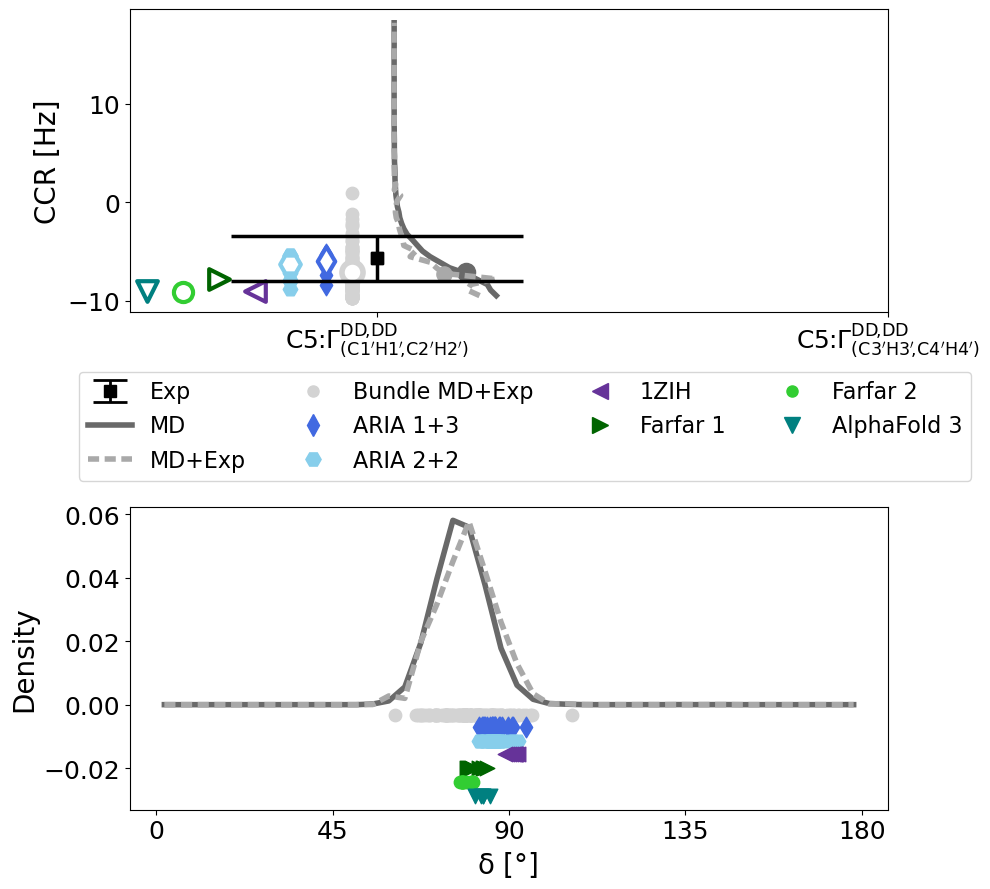

In [24]:
plot_angle_measurement('C5', 'delta', ['C1-C2', 'C3-C4'], 'hcch', save=False)

# Basepairs and stackings

In [25]:
def get_pairing(pairings, pair_idx): # pair_idx = [0,13]
    """Return Base pairs and basepair labels"""

    bp = []
    bp_labels = []
    for p in pairings:
        if pair_idx in p[0]: # Check for bp
    #         bp_c5_g10.append(p[1][p[0].index([4,9])]) # Use if collecting the bps only
            if p[1][p[0].index(pair_idx)][:2] == 'WC' or p[1][p[0].index(pair_idx)][:2] == 'WW':
                bp.append(0)
                bp_labels.append('WW/WC')
            elif p[1][p[0].index(pair_idx)][:2] == 'XX':
                bp.append(2)
                bp_labels.append('None') #bp_labels.append('XX')
            else:
                bp.append(1)
                bp_labels.append('non-WW/WC')
        else:
            bp.append(0)
            bp_labels.append('None')
    return np.array(bp), bp_labels

def get_stacking(stackings, pair_idx, stack_type):
    st = []
    st_labels = []
    for s in stackings:
        if pair_idx in s[0]:
            if s[1][s[0].index(pair_idx)] == stack_type:
                st.append(1)
                st_labels.append(stack_type)
            else:
                st.append(0)
                st_labels.append('None')
        else:
            st.append(0)
            st_labels.append('None')
            
    return st#, st_label

## Get Basepairs and Stackings

### From MD Simulation

In [26]:
traj_f   = f'gcaa_simulations/concat_traj_nopbc.xtc'
top_f    = f'gcaa_simulations/initial_nopbc_mdtraj.pdb'

stackings,pairings,residues = bb.annotate(traj_f,topology=top_f)

# Loading gcaa_simulations/concat_traj_nopbc.xtc 


### From Bundles

In [27]:
stacks_bundles, pairs_bundles, res_bundles = {}, {}, {}
for b in bundles:
    stacks_bundles[b], pairs_bundles[b], res_bundles[b] = bb.annotate(f'nmrbundle_data/Bundle_{b}.pdb')

# Loading nmrbundle_data/Bundle_1_3.pdb 
# Skipping unknown residue URI11 
# Loading nmrbundle_data/Bundle_2_2.pdb 
# Skipping unknown residue URI11 
c:\Users\david_leopold\anaconda3\Lib\site-packages\mdtraj\formats\pdb\pdbfile.py:200: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn('Unlikely unit cell vectors detected in PDB file likely '
# Loading nmrbundle_data/Bundle_1ZIH.pdb 
# Loading nmrbundle_data/Bundle_Farfar1.pdb 
# Loading nmrbundle_data/Bundle_Farfar2.pdb 
# Loading nmrbundle_data/Bundle_alphafold3.pdb 


['MD', 'MD+Exp', 'Bundle MD+Exp', 'ARIA 1+3', 'ARIA 2+2', '1ZIH', 'Farfar 1', 'Farfar 2', 'AlphaFold 3']


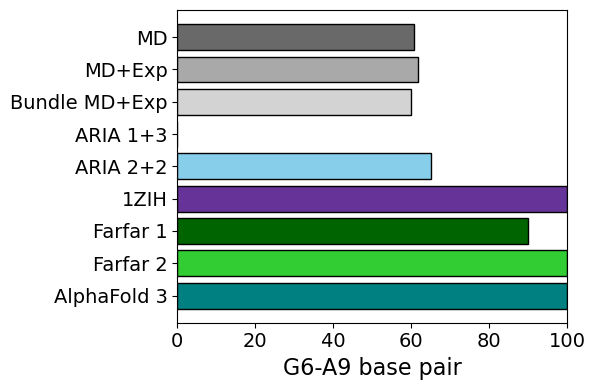

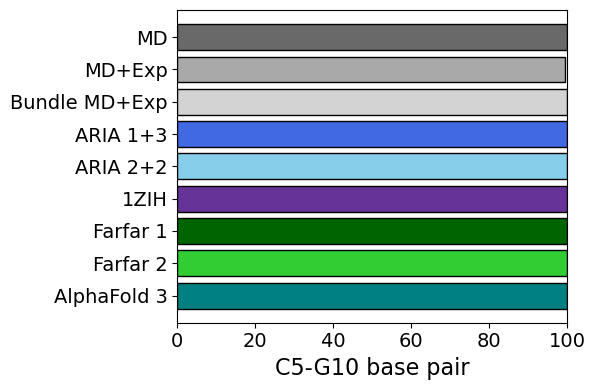

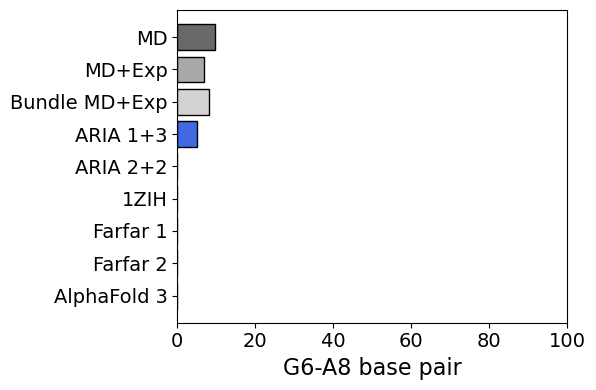

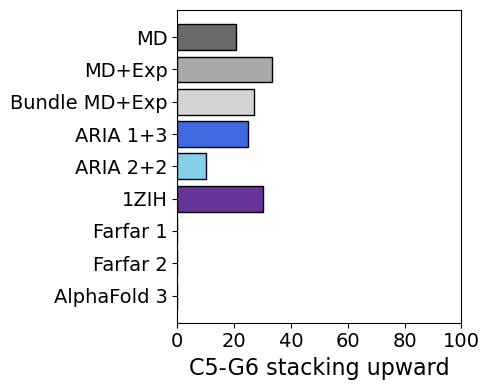

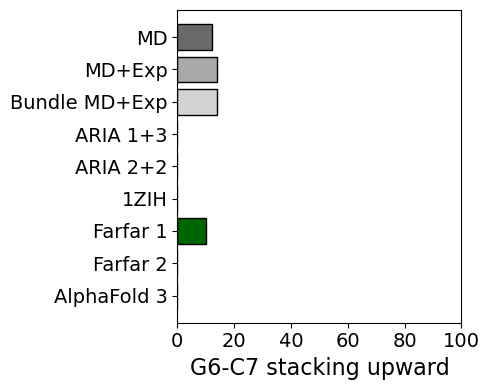

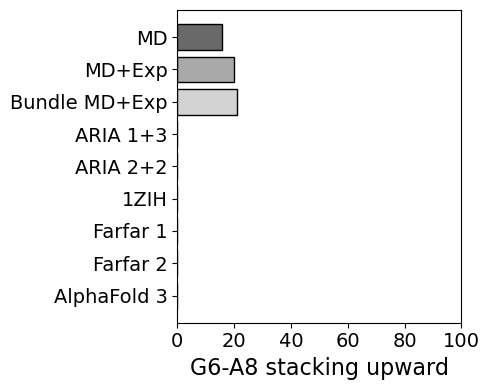

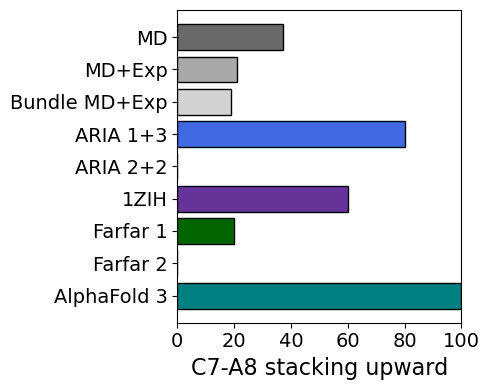

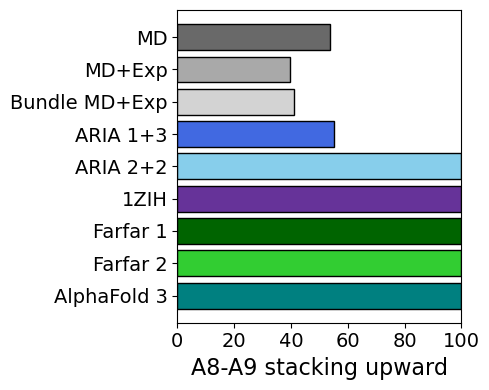

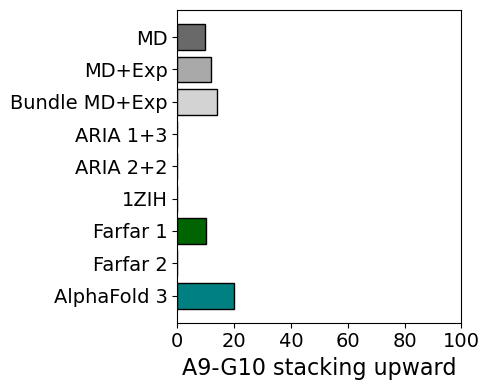

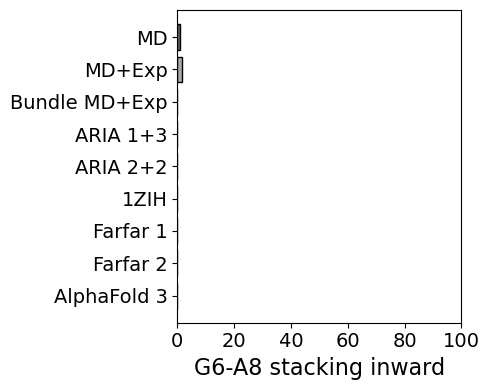

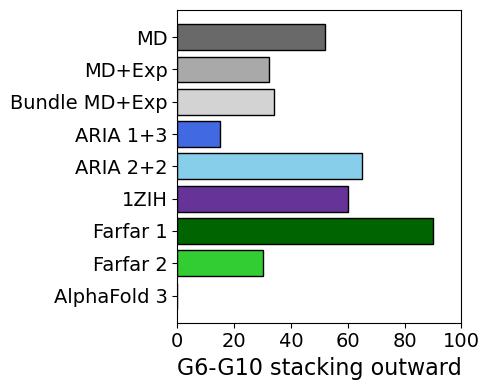

In [28]:
data_label = ['MD', 'MD+Exp','Bundle MD+Exp'] + bundle_labels
print(data_label)
#plt_coloring = ["dimgray","darkgray","lightgray","lightblue","lightcyan","aliceblue"]
plt_coloring = ["dimgray","darkgray","lightgray",'royalblue', 'skyblue', 'rebeccapurple', 'darkgreen', 'limegreen', 'teal'] # MD, MD+Exp, Bundle_MD+Exp, 1+3, 2+2, 1ZIH, far, far_top10, alpha3
# Here you can define all secondary structures you are looking for                                                  ##56B4E9', '#009E74', '#D55C00', '#F0E442', '#826aed', '#ff90b3'
requested_annotations = [
                            {"residues": ("G_6","A_9"), "type": "bp"},
                            {"residues": ("C_5","G_10"), "type": "bp"},
                            {"residues": ("G_6","A_8"), "type": "bp"},
                            
                            {"residues": ("C_5","G_6"), "type": "stack_up"},
                            {"residues": ("G_6","C_7"), "type": "stack_up"},
                            {"residues": ("G_6","A_8"), "type": "stack_up"},
                            {"residues": ("C_7","A_8"), "type": "stack_up"},
                            {"residues": ("A_8","A_9"), "type": "stack_up"},
                            {"residues": ("A_9","G_10"), "type": "stack_up"},

                            {"residues": ("G_6","A_8"), "type": "stack_in"},

                            {"residues": ("G_6","G_10"), "type": "stack_out"},

                        ]
plt_files = []
plt_labels = []

for i in range(len(requested_annotations)):
    data = []
    annot = requested_annotations[i] 
    barnaba_index = (annot["residues"][0]+"_0", annot["residues"][1]+"_0") # Barnaba uses specific index for annotation for ex. G_6_0 for G6
    plot_name = "".join(annot["residues"]) + "_" + annot["type"]

    # Check if annotation is basepair
    if annot["type"] == "bp":
        _,bp_labels = get_pairing(pairings, pair_idx=[residues.index(barnaba_index[0]), residues.index(barnaba_index[1])])
        data.append(100*sum([sum([1 if i == k else 0 for i in bp_labels]*w0) for k in ['WW/WC', 'non-WW/WC']]))
        data.append(100*sum([sum([1 if i == k else 0 for i in bp_labels]*w_rew) for k in ['WW/WC', 'non-WW/WC']]))
        data.append(100*sum([sum([1 if i == k else 0 for i in np.array(bp_labels)[frames]]*np.full(len(frames), 1/len(frames))) for k in ['WW/WC', 'non-WW/WC']]))

        for ff,b in enumerate(bundles):
            _,bp_labels = get_pairing(pairs_bundles[b], pair_idx=[ res_bundles[b].index(barnaba_index[0]), res_bundles[b].index(barnaba_index[1])])
            p_bundle = 100*sum([np.average([1 if i == k else 0 for i in bp_labels]) for k in ['WW/WC', 'non-WW/WC']])
            data.append(p_bundle)


    # Check if annotation is inward stacking
    elif "stack" in annot["type"]:
        # Check if outward or inward stacking
        if annot["type"] == "stack_out":
            stack_type = "<>"
        elif annot["type"] == "stack_down":
            stack_type = "<<"
        elif annot["type"] == "stack_up":
            stack_type = ">>"
        elif annot["type"] == "stack_in":
            stack_type = "><"
        data.append(100*sum(get_stacking(stackings, [residues.index(barnaba_index[0]), residues.index(barnaba_index[1])], stack_type)*w0))
        data.append(100*sum(get_stacking(stackings, [residues.index(barnaba_index[0]), residues.index(barnaba_index[1])], stack_type)*w_rew))
        data.append(100*sum(np.array(get_stacking(stackings, [residues.index(barnaba_index[0]), residues.index(barnaba_index[1])], stack_type))[frames])/len(frames))

        for ff,b in enumerate(bundles):
            # _,g6_a9_md = get_pairing(pairs_bundles[f], pair_idx=[ res_bundles[f].index('G_6_0'), res_bundles[f].index('A_9_0')])
            p_bundle = 100*sum(get_stacking(stacks_bundles[b], [res_bundles[b].index(barnaba_index[0]), res_bundles[b].index(barnaba_index[1])], stack_type))/len(stacks_bundles[b])
            data.append(p_bundle)

    # Plot
    if annot["type"] == "bp":
        fig, ax = plt.subplots(figsize=[(20/3.3),4])
    else:
        fig, ax = plt.subplots(figsize=[5,4])
    

    
    bars = ax.barh(data_label[::-1], data[::-1],color=plt_coloring[::-1],edgecolor = "k")
    
    #ax.bar_label(bars, fmt=" {:,.2f}%")
    ax.set_xlim(0,100)
    if  annot["type"] == "bp":
        typ = "base pair"
    elif annot["type"] == "stack_out":
        typ = "stacking outward"
    elif annot["type"] == "stack_in":
        typ = "stacking inward"
    elif annot["type"] == "stack_up":
        typ = "stacking upward"
    elif annot["type"] == "stack_down":
        typ = "stacking downward"
    res0 = f'{annot["residues"][0].split("_")[0]}{annot["residues"][0].split("_")[1]}'
    res1 = f'{annot["residues"][1].split("_")[0]}{annot["residues"][1].split("_")[1]}'
    plt.xlabel(f'{res0}-{res1} {typ}', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    

    plt.tight_layout(w_pad=5)
    out_dir = f"plots/{tag}/basepair_stacking_analysis"
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
    plt.savefig(f'{out_dir}/{plot_name}.pdf')
    plt.savefig(f'{out_dir}/{plot_name}.png')
    plt.show()
    plt_files.append(f'{out_dir}/{plot_name}.png')
    plt_labels.append(plot_name)

In [29]:
for i in range(len(requested_annotations)):
    print(f'{annot["residues"][0].split("_")[0]}{annot["residues"][0].split("_")[1]}')
    #print(f'{annot["residues"][0]}-{annot["residues"][1]} {typ}')

G6
G6
G6
G6
G6
G6
G6
G6
G6
G6
G6


# SI Fig: CCR/3J + angle

In [30]:
j3_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_j3_bme.dat", delim_whitespace=True, usecols=[0]).index)
j3_lbl = [ f"{i.split('-')[0]}:{i.split('-')[1]}" for i in j3_lbl ]

In [ ]:
def get_measurement_idx(lbl_list, res, measurement):
    lbl = f'{res}:{measurement}'
    idx = lbl_list.index(lbl)
    return idx

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx #array[idx]

#bundle_labels = bundles

cc = ['royalblue', 'skyblue', 'rebeccapurple','darkgreen', 'limegreen', 'teal'] 
def plot_angle_measurement_si(res, angle, measurements, mtype, save=False):
    
    if(angle=="delta"):
        bins=np.linspace(0,180,45)
        # bins=np.linspace(0,360,90)
        ang_add = 0
    elif(angle=="alpha" or angle == "beta" or angle == "gamma" or angle == "zeta" or angle == "eps" or angle=="chi"):
        # tors[np.where(tors<0)] += 2*np.pi
        ang_add = 360
        bins=np.linspace(0,360,90)
    else:
        bins=np.linspace(-180,180,90)

    idxs, xticks = [],[]
    for m in measurements:
        if mtype == 'hcch':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = hcch_exp, hcch_calc, hcch_bundles, hcch_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'hcn':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = hcn_exp, hcn_calc, hcn_bundles, hcn_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'hcp':
            # idxs.append(get_measurement_idx(ccr_lbl, res, m))
            data_e, data_c, data_b, data_lbl = hcp_exp, hcp_calc, hcp_bundles, hcp_lbl
            ylbl = 'CCR [Hz]'
        elif mtype == 'j3':
            # idxs.append(get_measurement_idx(j3_lbl, res, m))
            data_e, data_c, data_b, data_lbl = j3_exp, j3_calc, j3_bundles, j3_lbl
            ylbl = r'$\mathregular{^3J}$ [Hz]'
        else:
            print('Check measurement type!')
            break
        if f'{res}:{m}' in data_lbl: 
            idxs.append(get_measurement_idx(data_lbl, res, m))
            #xticks.append(f'{res}:{m}')
            xticks.append(f'{res}:{lbl_dict_[m]}')
        else:
            continue

    fig, ax = plt.subplots(2,1, figsize=[10,9])
    ###### UPPER PANEL ######
    err_ = None
    for i,idx in enumerate(idxs):
        # Exp:
        err_ = ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', ls='', markersize=9, elinewidth=2, capthick=2, capsize=10, zorder=10, label='Exp') # just for the legend
        ax[0].errorbar(1+i, data_e[idx,0], yerr=data_e[idx,1], c='k', marker='s', markersize=9, elinewidth=2, capthick=2.5, capsize=25*len(bundle_labels), zorder=10) #capsize=10
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='dimgrey', lw=4, zorder=8)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx]))], np.average(data_c[:,idx]), marker='o', s=170, edgecolor=None, color='dimgrey', zorder=8.5)
        # MD:
        hh, ee = np.histogram(data_c[:,idx], bins=50, density=True, weights=w_rew)
        ax[0].plot((hh/hh.max()*0.3)+(1.03+i), 0.5*(ee[1:] + ee[:-1]), c='darkgrey', lw=4, ls='--', dashes=(2,1), zorder=9)
        ax[0].scatter(np.array((hh/hh.max()*0.3)+(1.03+i))[find_nearest(0.5*(ee[1:] + ee[:-1]), np.average(data_c[:,idx], weights=w_rew))], np.average(data_c[:,idx], weights=w_rew), marker='o', s=120, edgecolor=None, color='darkgrey',zorder=9.5)
        # MD+Exp bundle:
        ax[0].scatter([0.93+i]*len(frames), data_c[frames,idx], s=80, marker='o', color='lightgrey')#, alpha=0.7)
        ax[0].scatter([0.93+i], np.average(data_c[frames,idx], axis=0), s=230, marker='o', edgecolor='lightgrey', color='w', linewidths=4)
        # NMR Bundles + 1RNG:
        for b,bun in enumerate(bundles):
            ax[0].scatter([0.85+i-(0.08*b)]*len(data_b[bun]), data_b[bun][:,idx], s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)
            ax[0].scatter([0.85+i-(0.08*b)], np.average(data_b[bun][:,idx], axis=0), s=msizes[b]+110, marker=markers[b], edgecolor=cc[b], color='w', linewidths=3)

    ax[0].set_xlim(0.3,3.4)
    ax[0].set_xticks(np.arange(1, len(xticks)+1))
    ax[0].set_xticklabels(xticks)        
    ax[0].tick_params(axis='both', which='major', labelsize=18)
    ax[0].set_ylabel(ylbl, fontsize=20)
    ###### LOWER PANEL ######
    # MD:
    # tors[np.where(tors<0)] += 2*np.pi
    aa = aa_md[:,int(res[1:])-5,angles_bb.index(angle)]
    aa[np.where(aa<0)] += ang_add
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w0)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='dimgrey', lw=4, label='MD')
    # MD+Exp:
    hh,ee = np.histogram(aa, bins=bins, density=True, weights=w_rew)
    ax[1].plot(0.5*(ee[1:]+ee[:-1]), hh, c='darkgrey', lw=4, ls='--', label='MD', dashes=(2,1))
    # MD+Exp bundle:
    ax[1].scatter(aa[frames], [-0.18/180*np.pi]*len(aa[frames]), s=80, marker='o', color='lightgrey')#, alpha=0.7)
    # NMR bundles and 1RNG:
    for b,bun in enumerate(bundles):
        aa = aa_bundles[bun][:,int(res[1:])-5,angles_bb.index(angle)]
        aa[np.where(aa<0)] += ang_add

        ax[1].scatter(aa, [(-b/5/180*np.pi)-0.4/180*np.pi]*len(aa), s=msizes[b], marker=markers[b], color=cc[b])#, alpha=0.7)

    ax[1].set_xticks(np.arange(0,bins.max()+1,bins.max()/4))
    # ax[1].set_xticklabels(xticks)
    ax[1].tick_params(axis='both', which='major', labelsize=18)
    if angle=='eps':
        angle = 'epsilon'
    ax[1].set_xlabel(r'$\mathregular{{s1}}$ [$\degree$] '.replace('s1', '\\'+angle), fontsize=20)
    ax[1].set_ylabel('Density', fontsize=20)
    
    handles1 =  [#plt.Line2D([0], [0], lw=4, ls='', color='k', marker='s', label='Exp'),
                 plt.Line2D([0], [0], lw=4, color='dimgrey', label='MD'),
                 plt.Line2D([0], [0], lw=4, ls='--', dashes=(2,1), color='darkgrey', label='MD+Exp'),
                 plt.Line2D([0], [0], lw=4, ls='', color='lightgrey', marker='o', markersize=8, label='Bundle MD+Exp')]
    handles2 =  [plt.Line2D([0], [0], lw=4, ls='', color=cc[i], marker=markers[i], markersize=msizes[i]/10, label=ii) for i,ii in enumerate(bundle_labels) ]
    if err_:
        fig.legend(handles=[item for sublist in [[err_], handles1, handles2] for item in sublist], fontsize=16, ncol=4, loc='center', bbox_to_anchor=(0.52, 0.53), fancybox=True) #, edgecolor='k'
    else:
        fig.legend(handles=[item for sublist in [handles1, handles2] for item in sublist], fontsize=16, ncol=3, loc='center', bbox_to_anchor=(0.52, 0.53), fancybox=True) #, edgecolor='k'

    plt.tight_layout(h_pad=9.5)
    if save == True:
        plt.savefig(f'plots/angles/{res}_{angle}_{mtype}.pdf')
        plt.savefig(f'plots/angles/{res}_{angle}_{"_".join(measurements)}.png', dpi=300)
        #plt.savefig(f'plots/{res}_{angle}_{mtype}.png', dpi=300)
    plt.show()
    return err_

In [32]:
loop_res = ['C5','G6', 'C7', 'A8', 'A9','G10']

## $\chi$

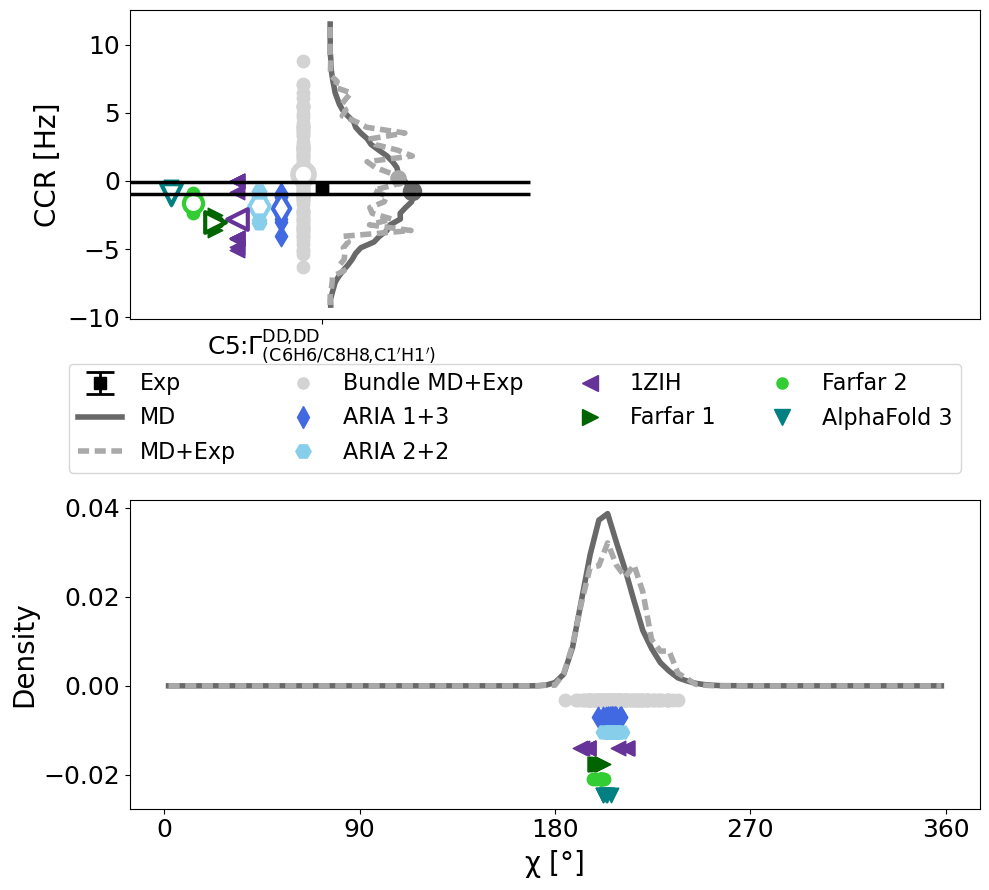

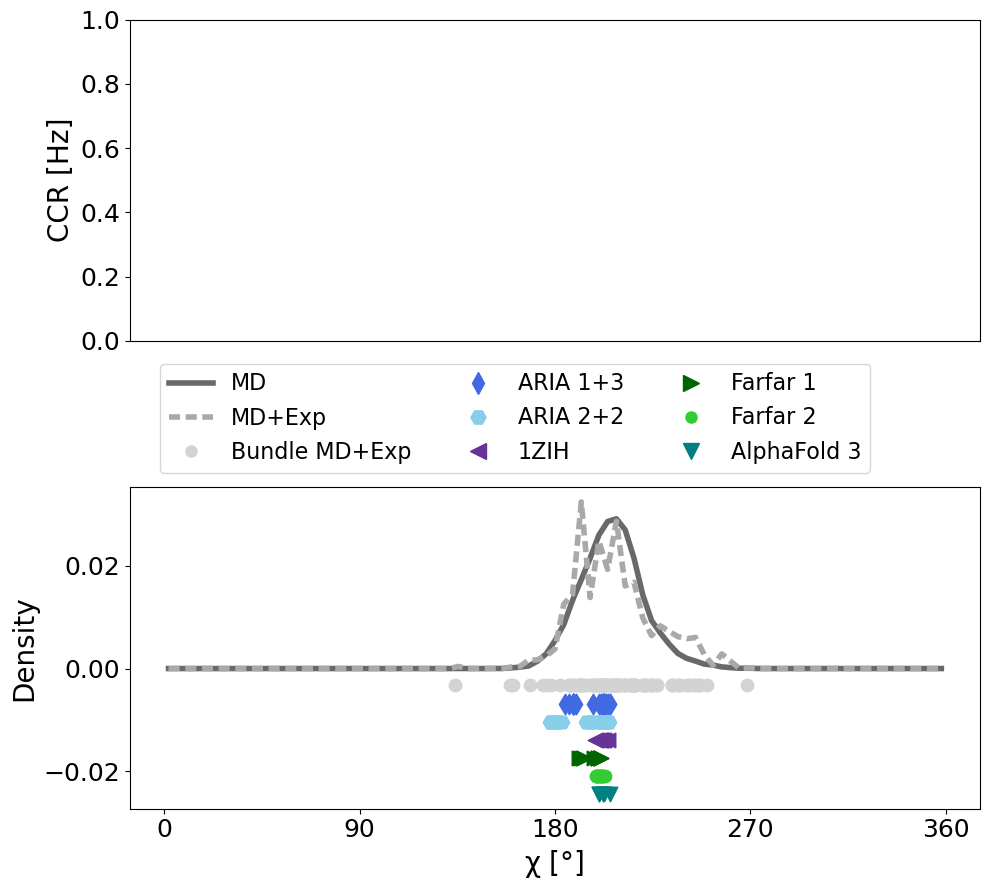

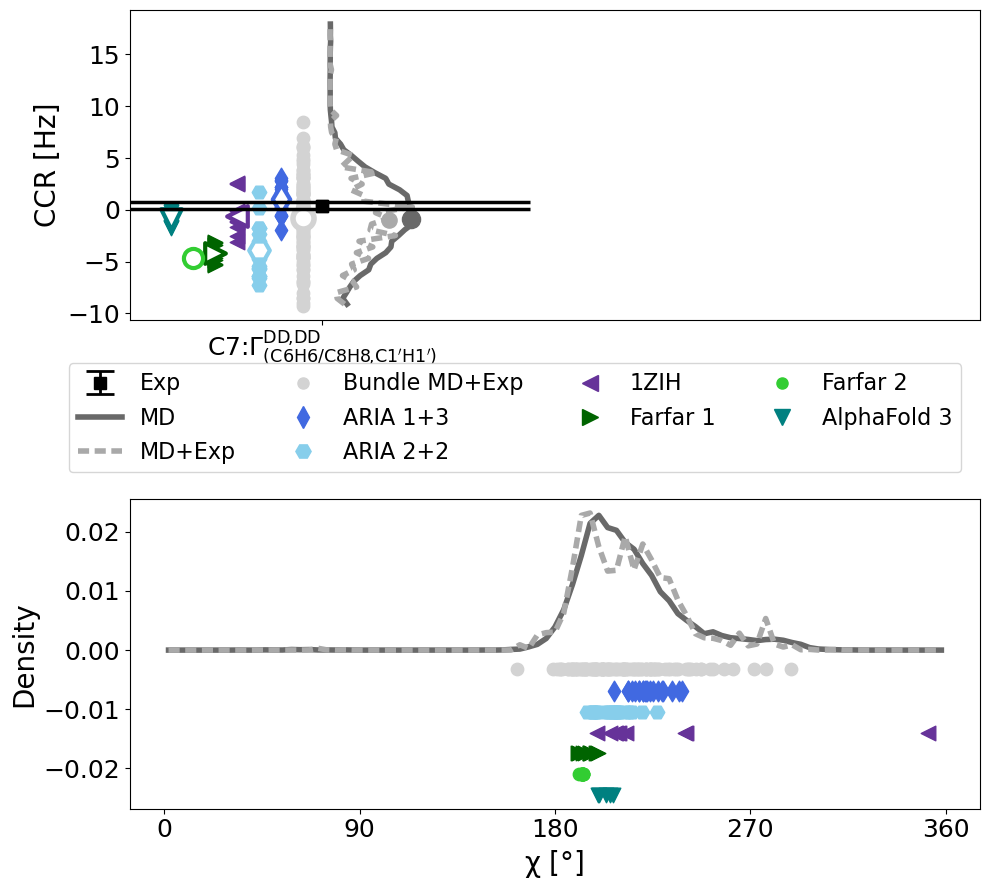

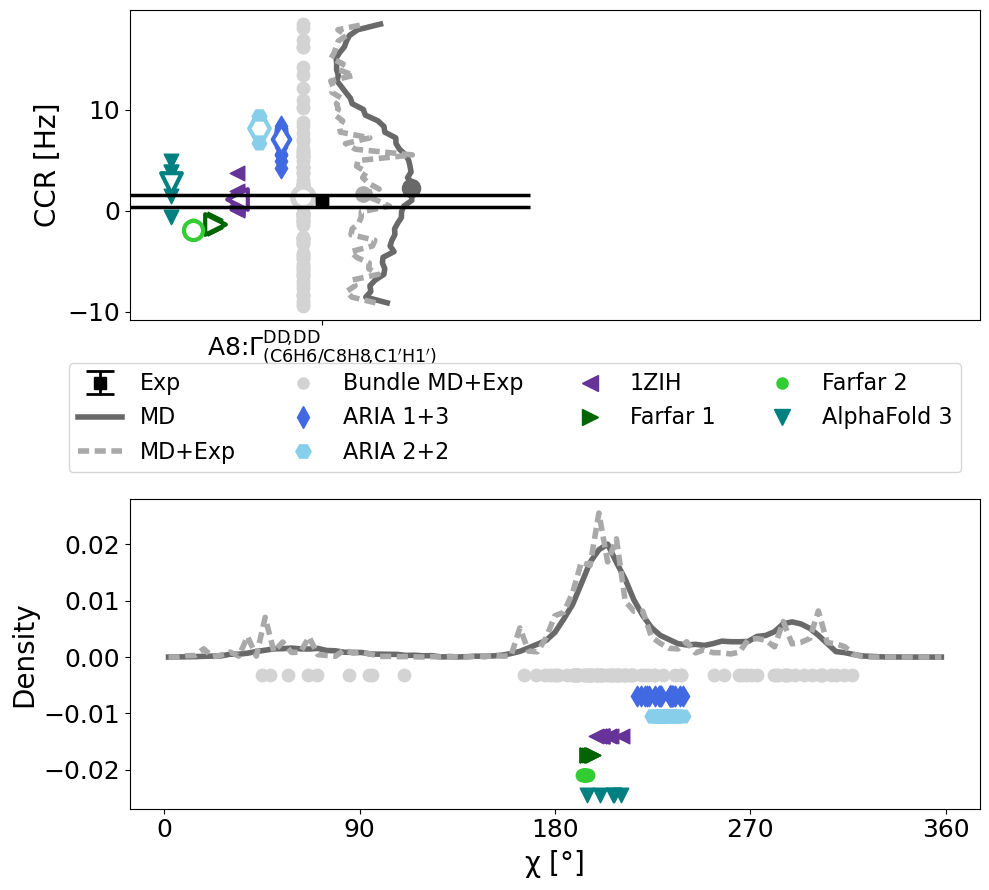

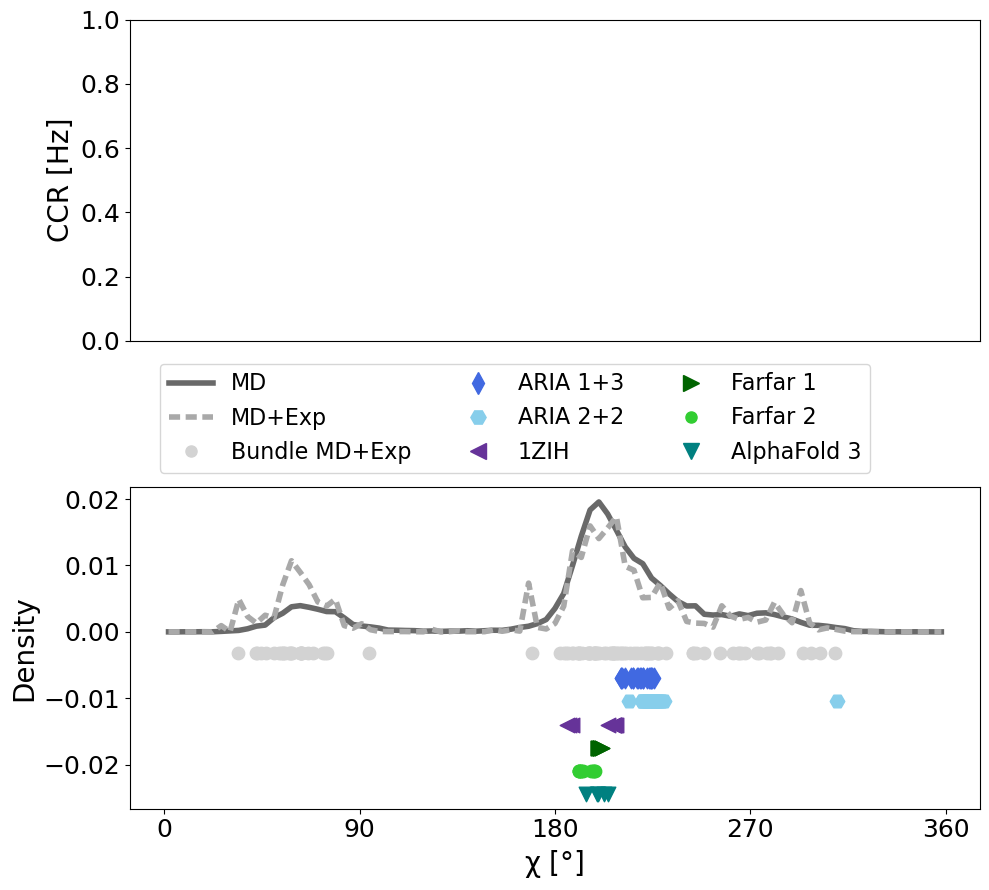

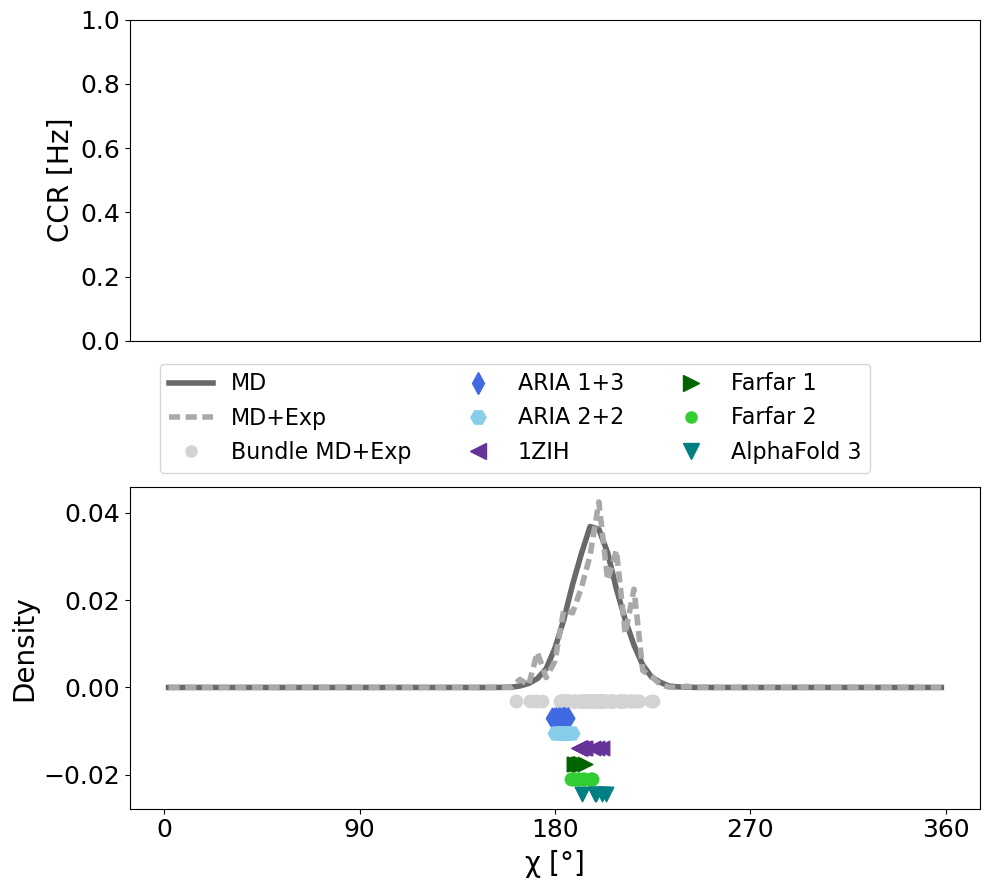

In [33]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'chi', ["C1-CC"], 'hcn', save=True)    

## $\alpha$

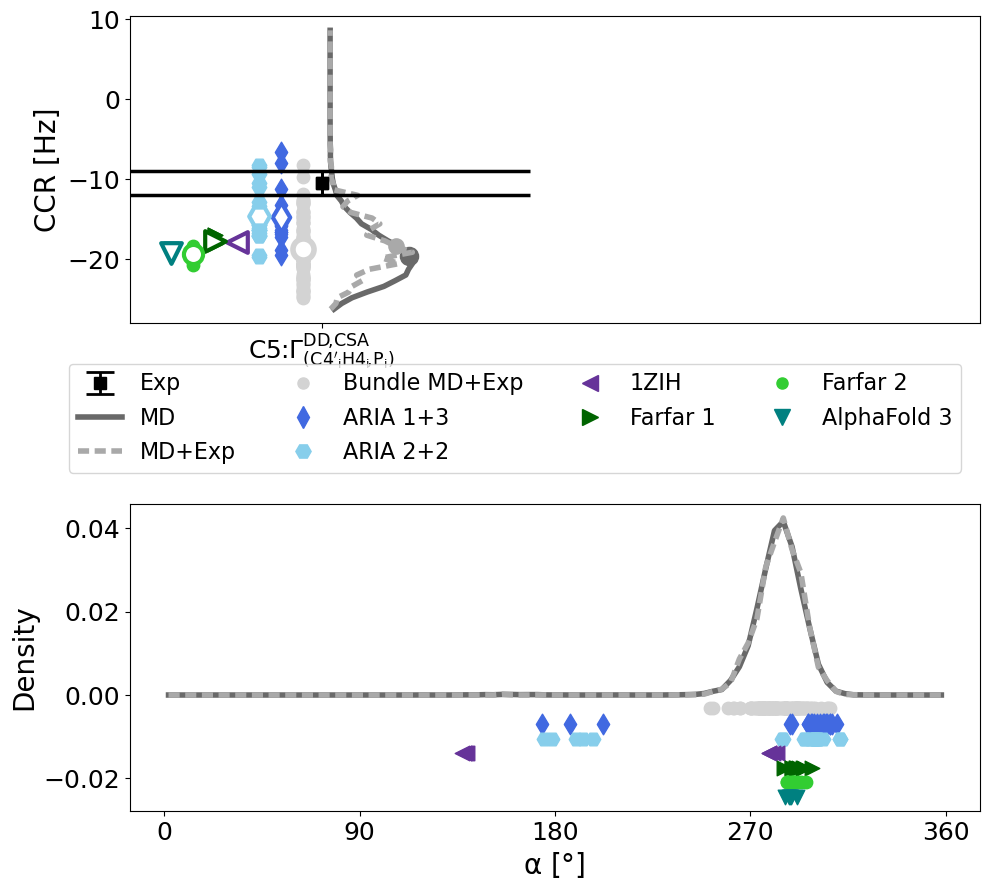

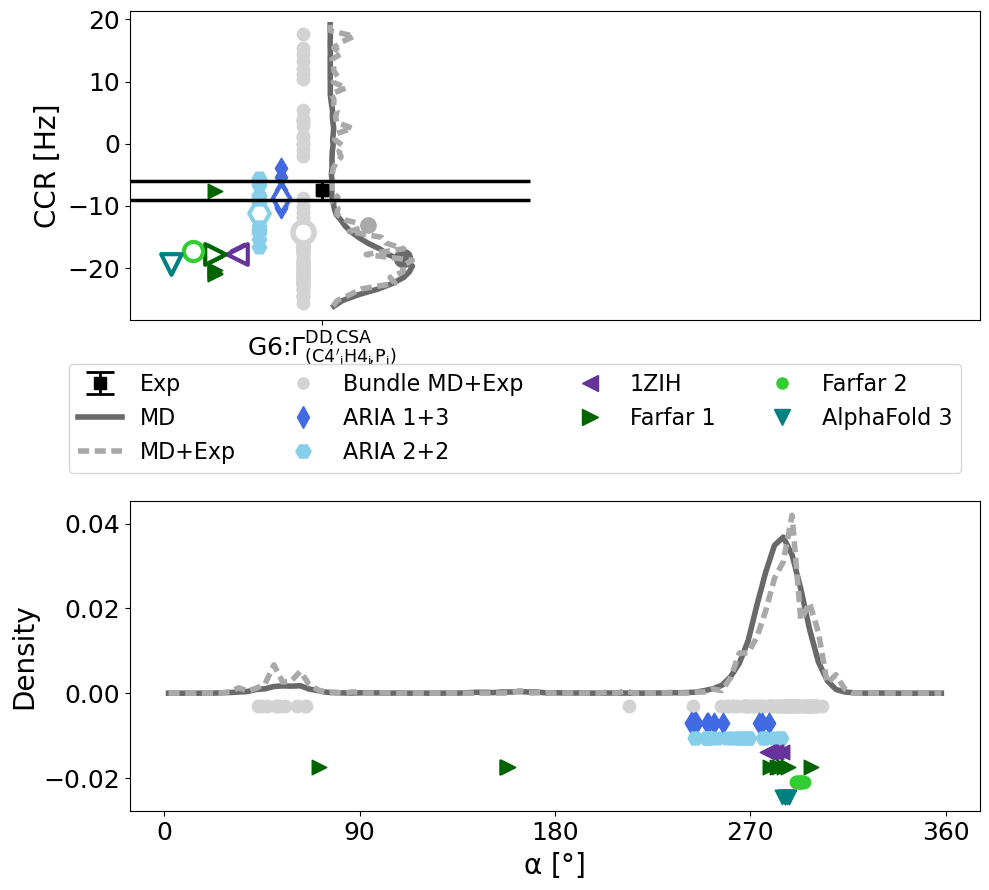

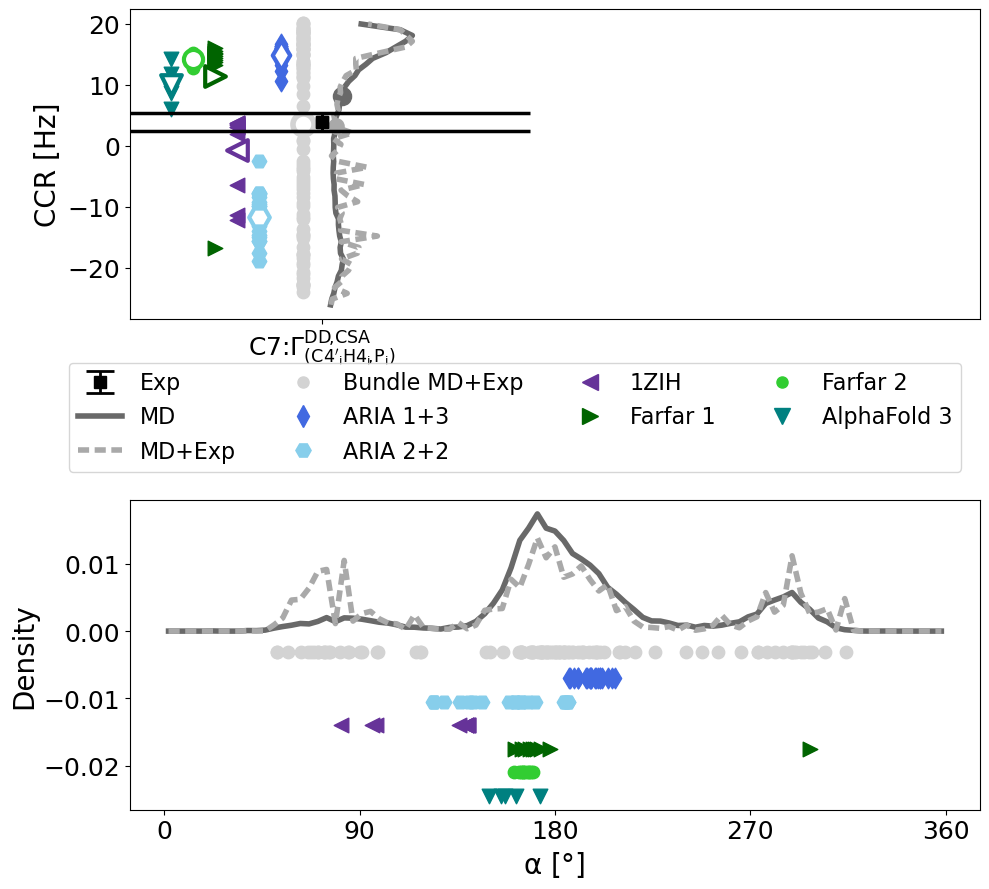

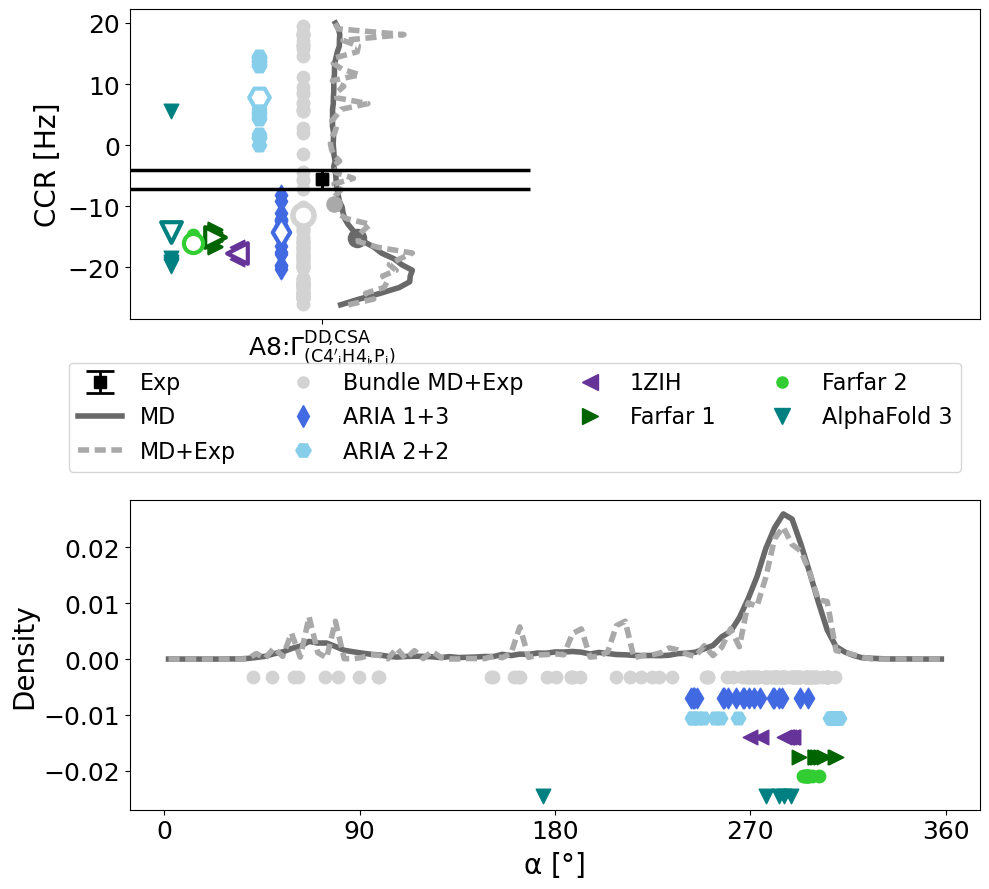

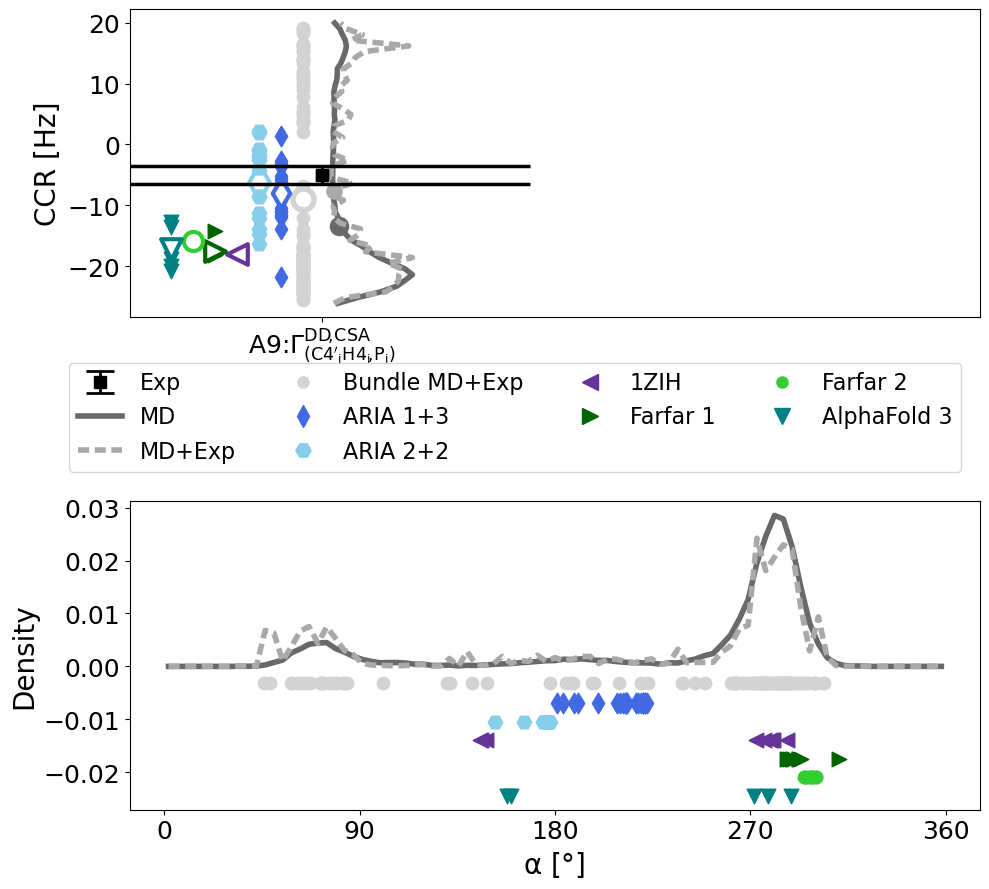

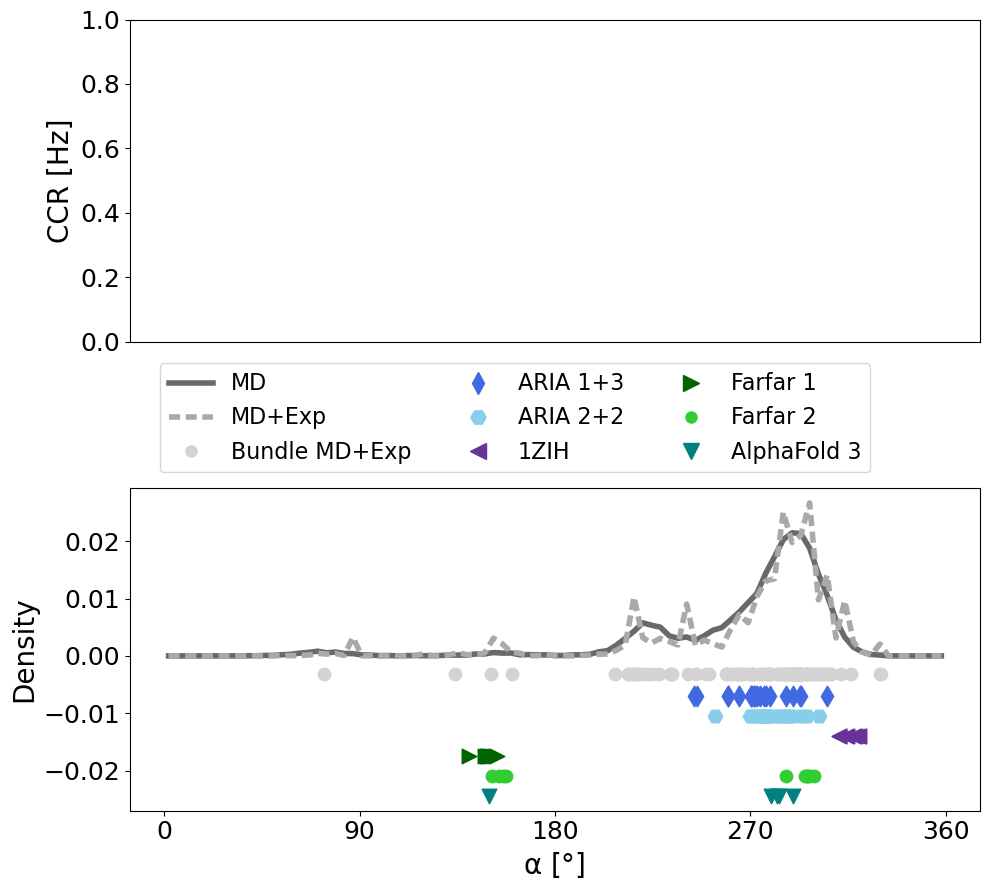

In [34]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'alpha', ['C4p-P'], 'hcp', save=True)

## $\beta$

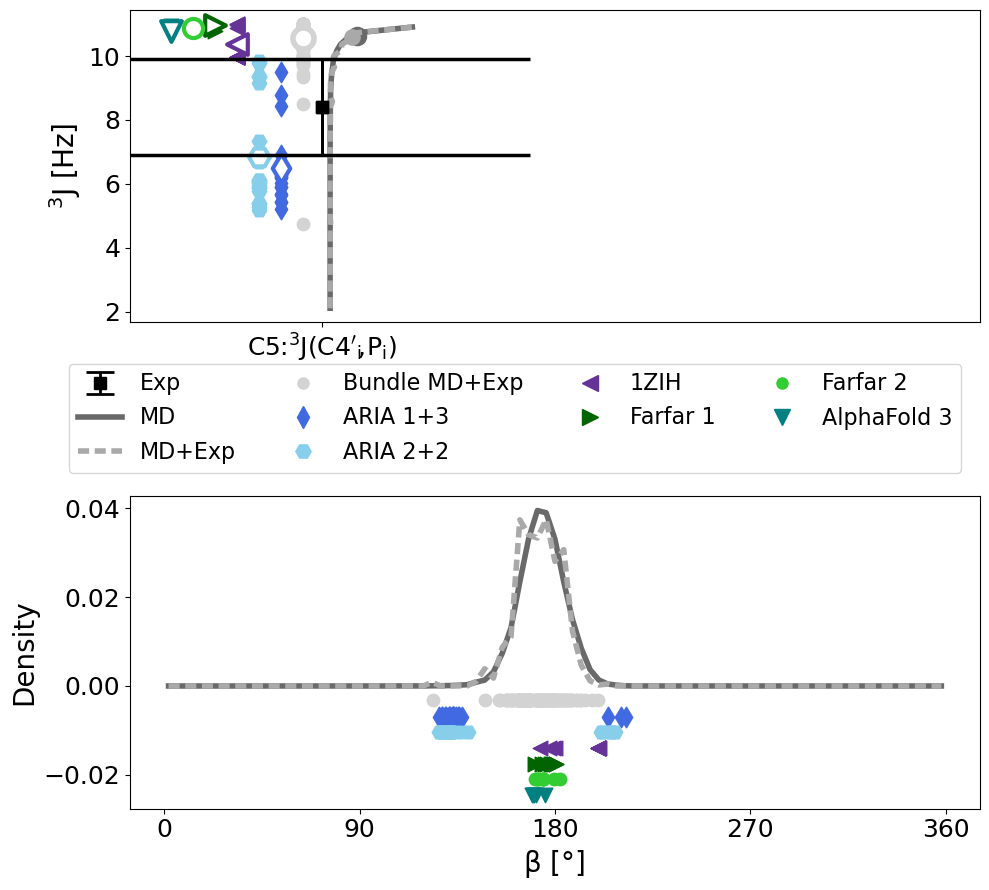

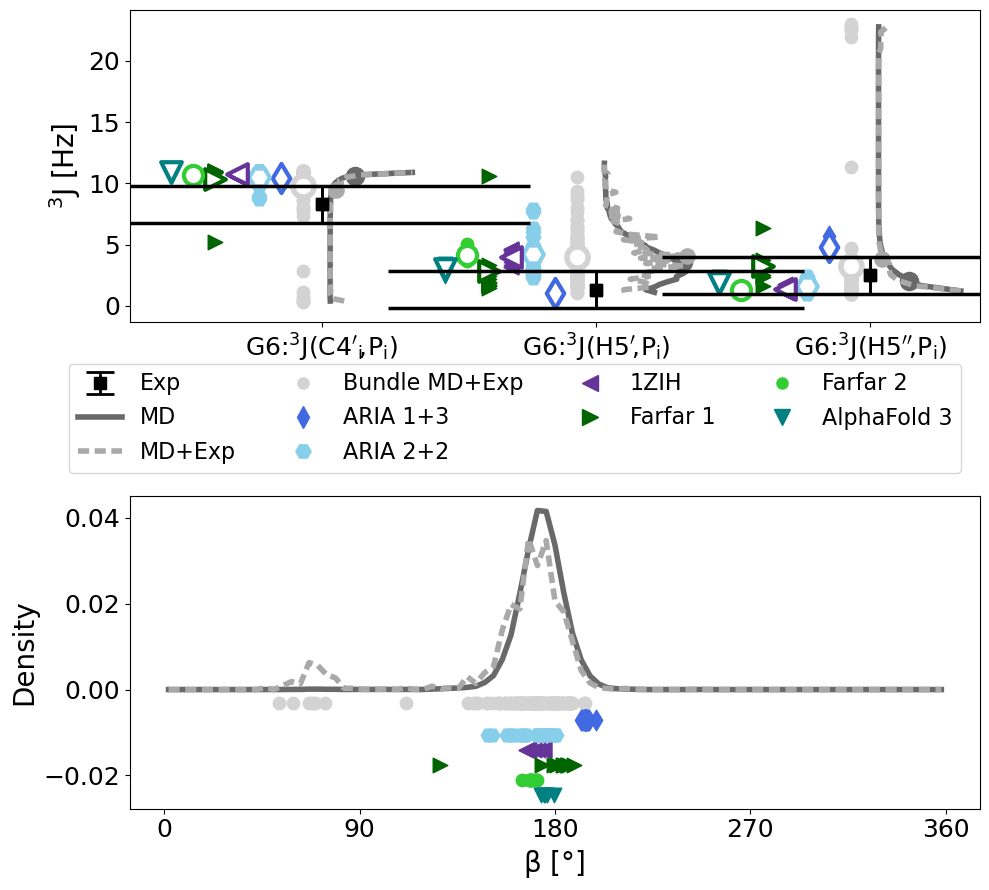

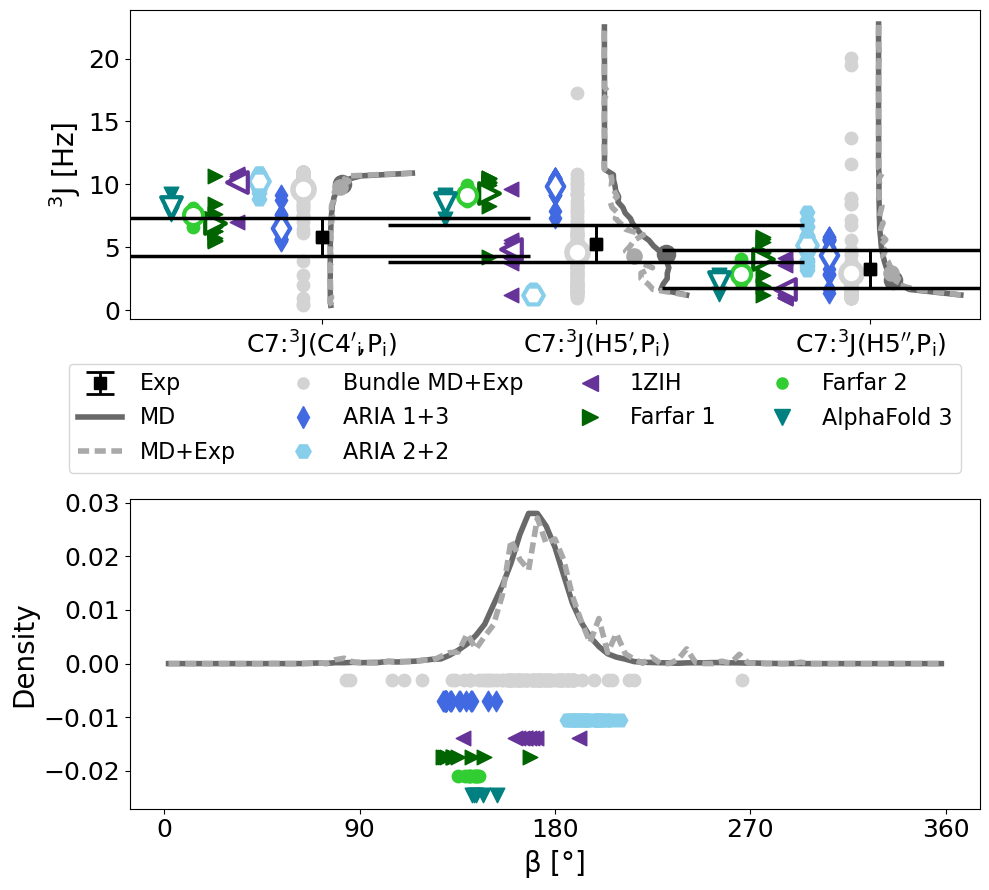

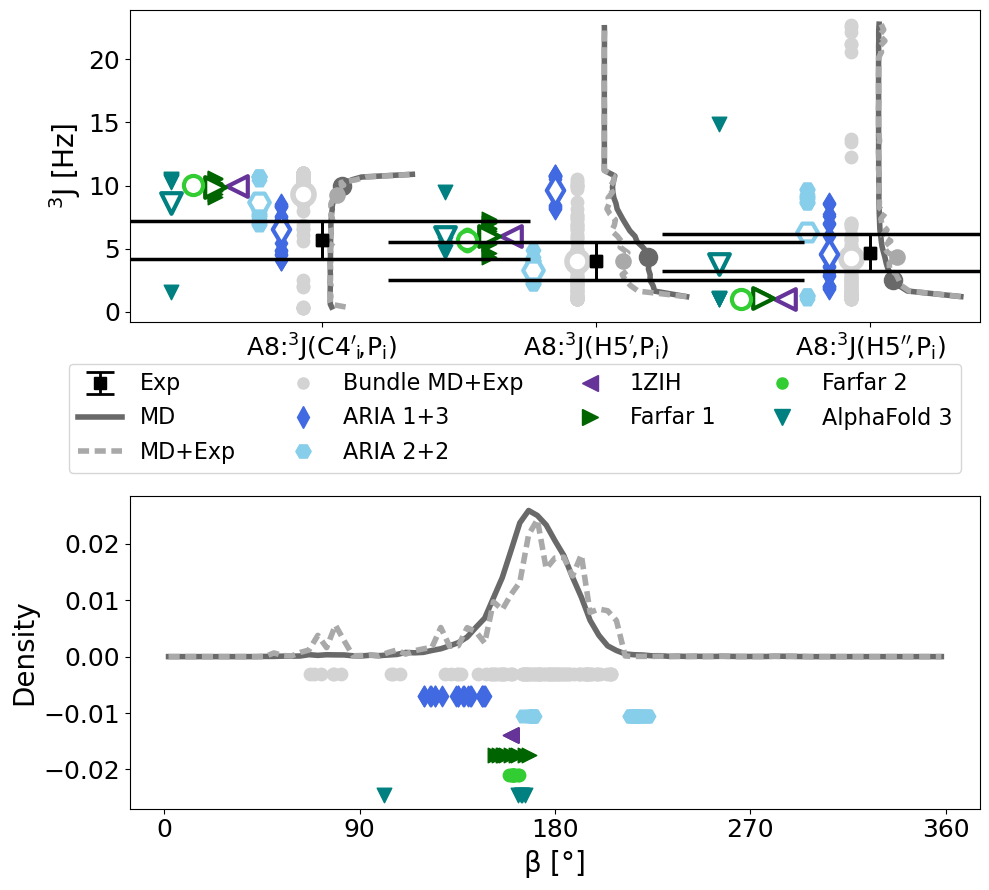

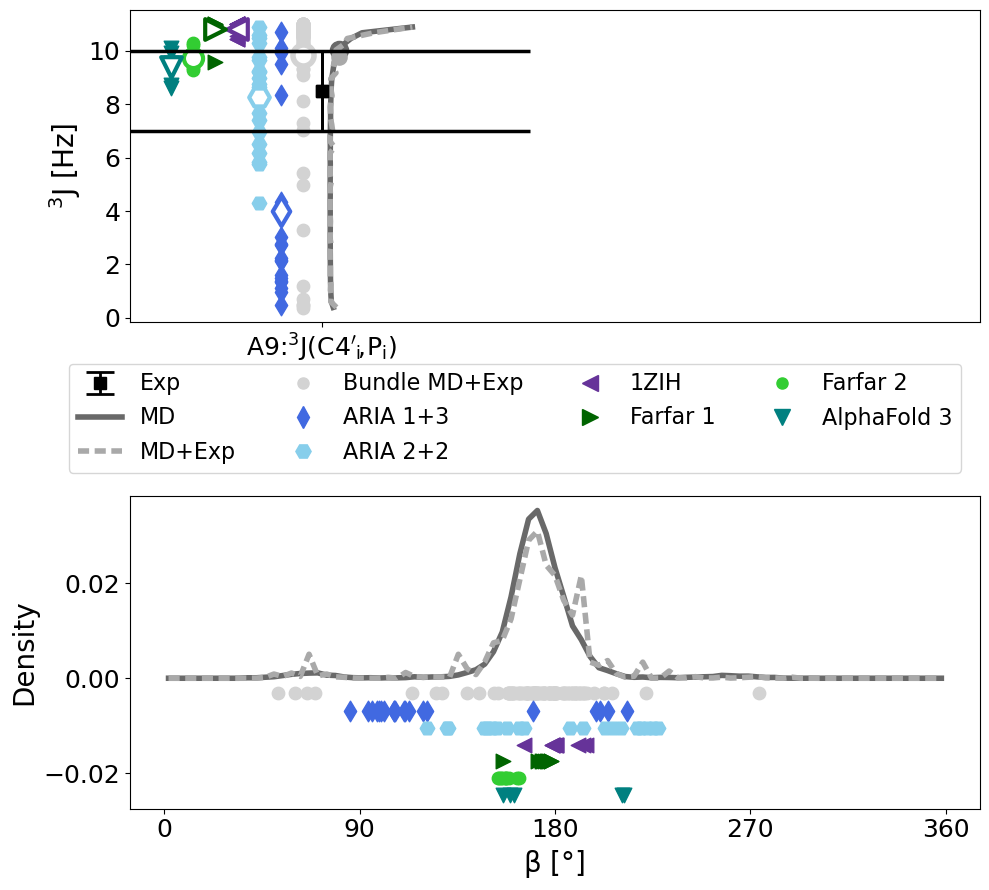

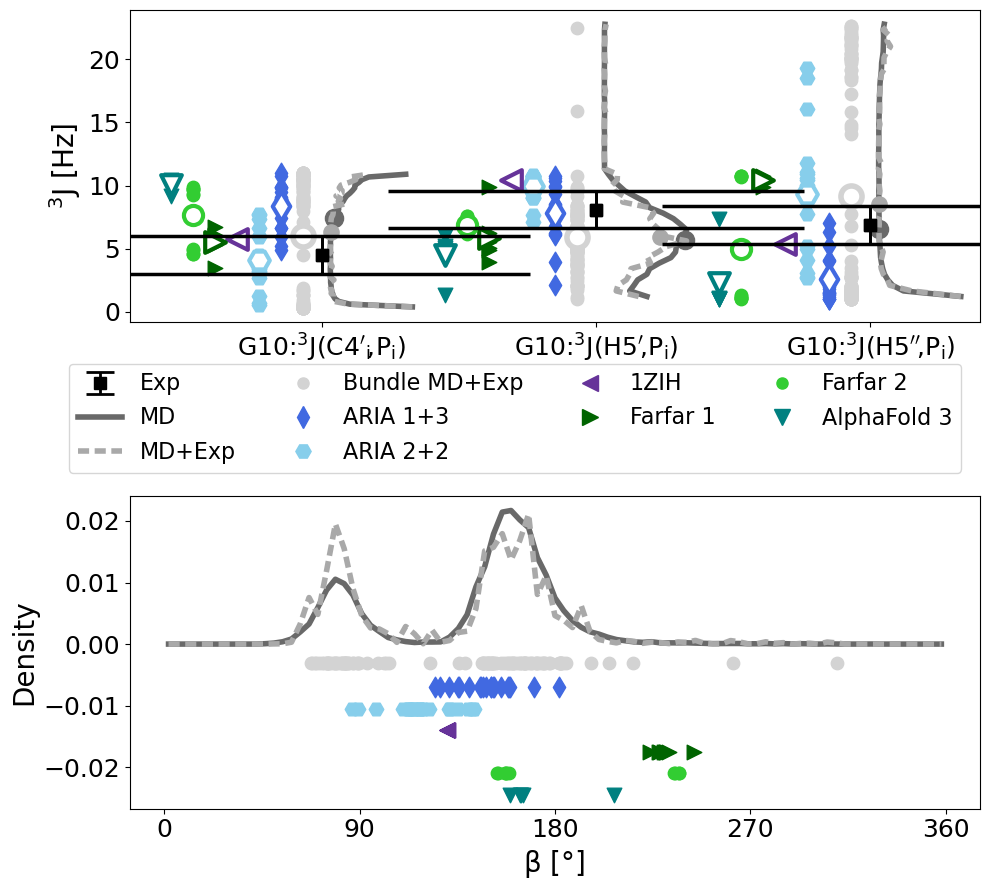

In [35]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'beta', ['C4Pb', '1H5P', '2H5P'], 'j3', save=True)

## $\gamma$

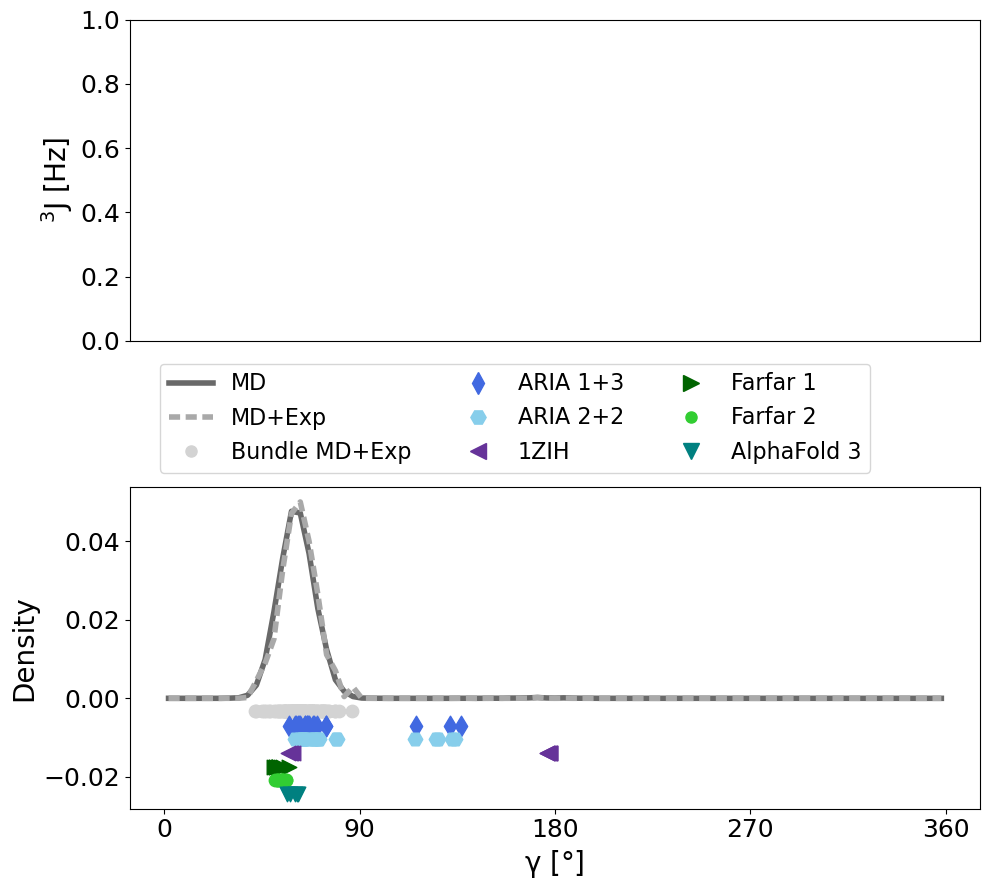

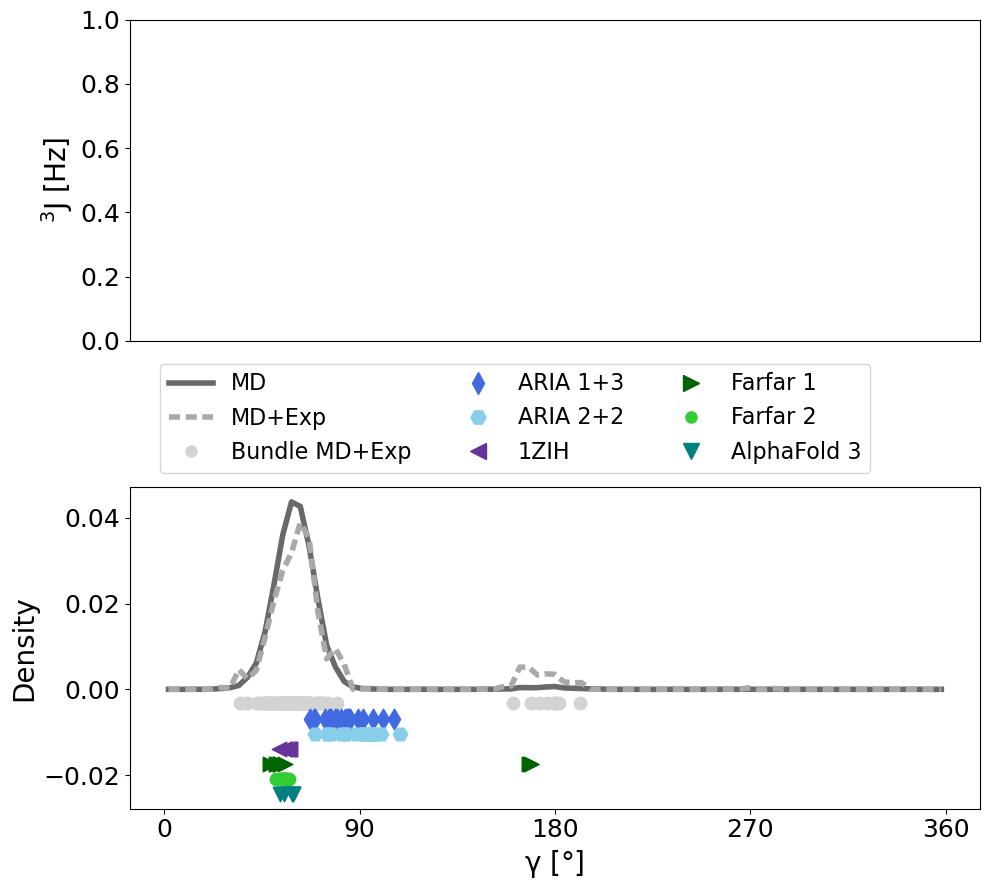

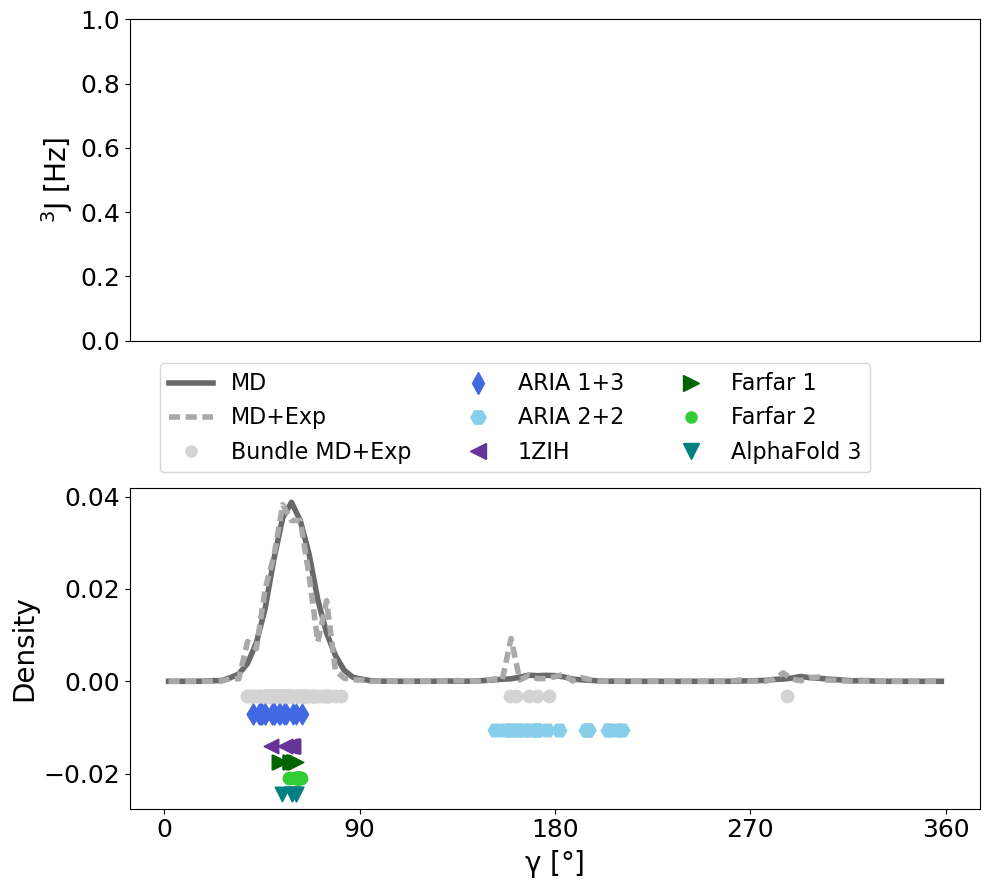

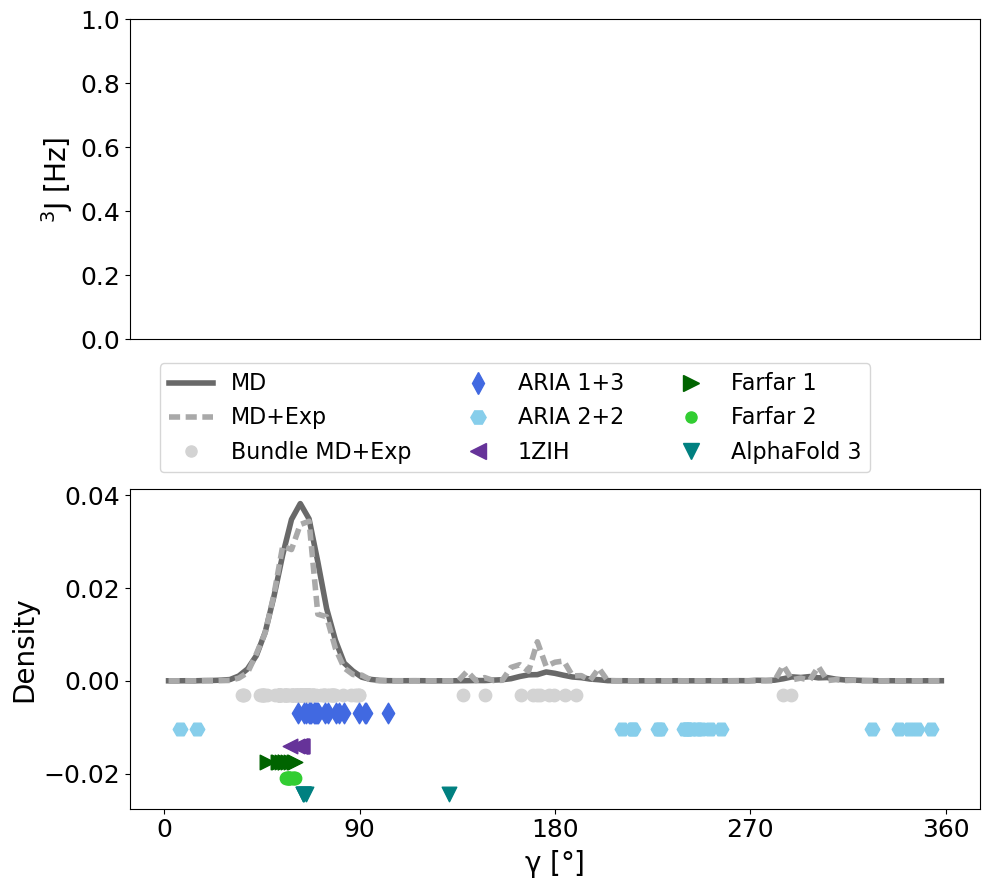

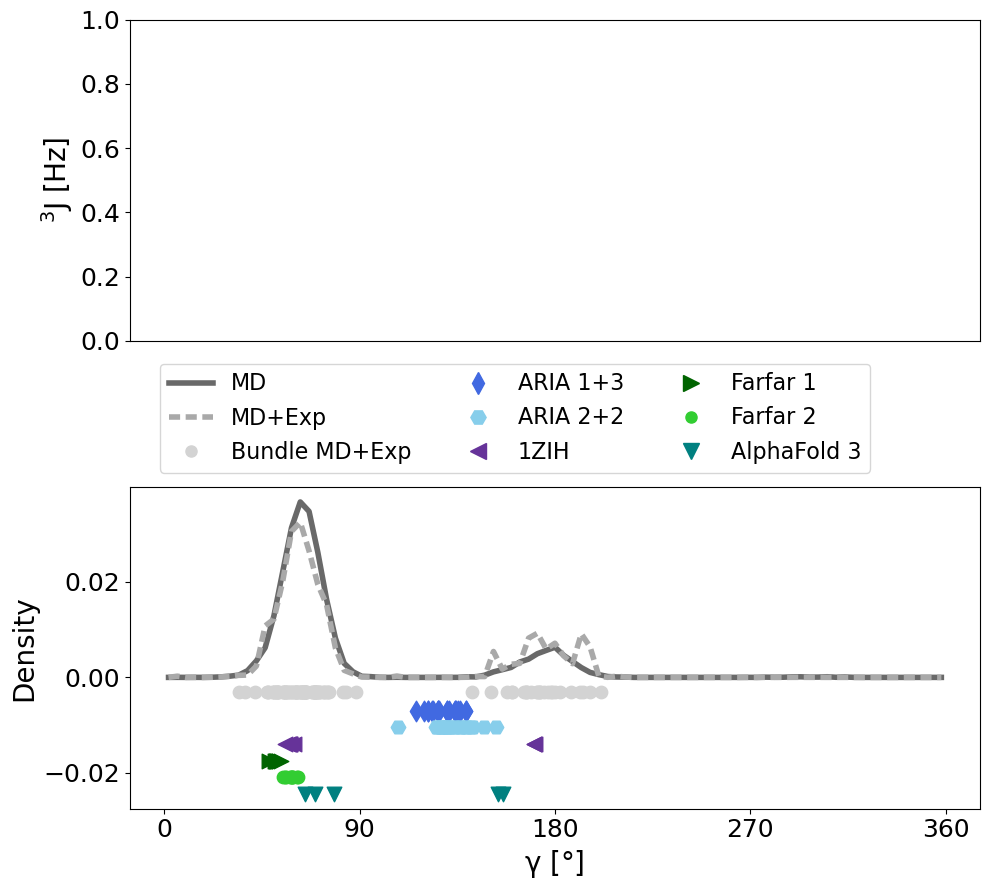

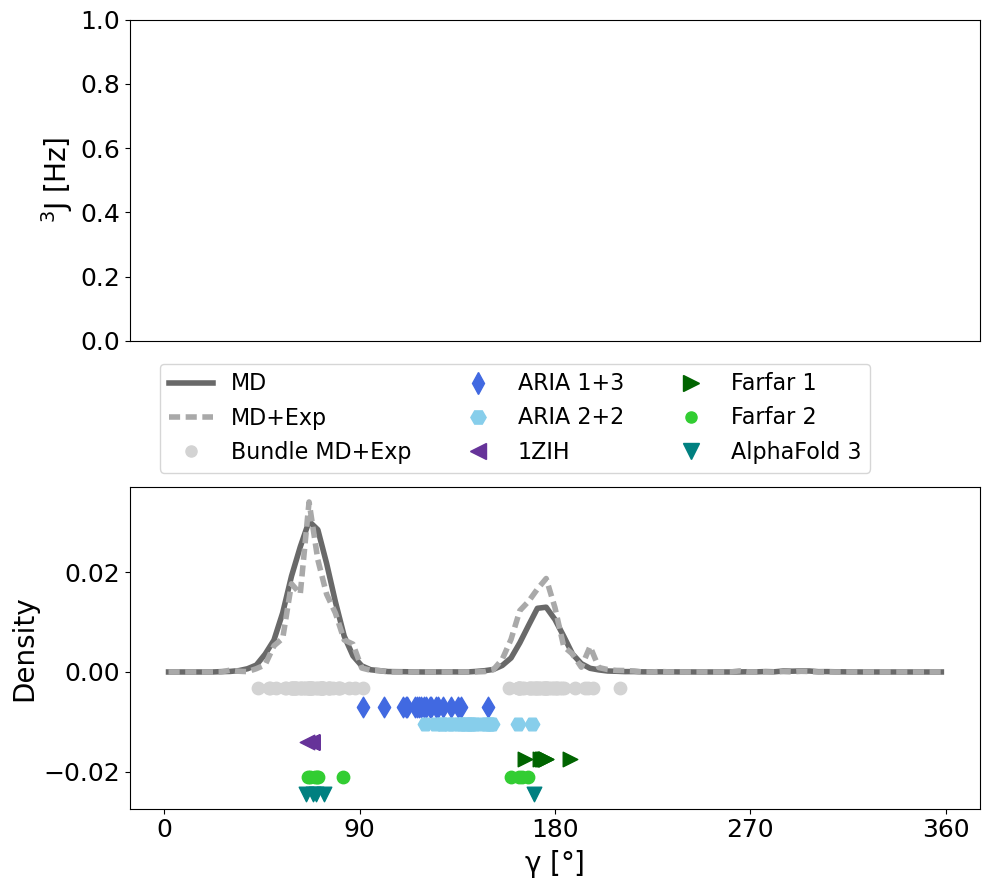

In [36]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'gamma', ['1H5H4', '2H5H4'], 'j3', save=True)

## $\delta$

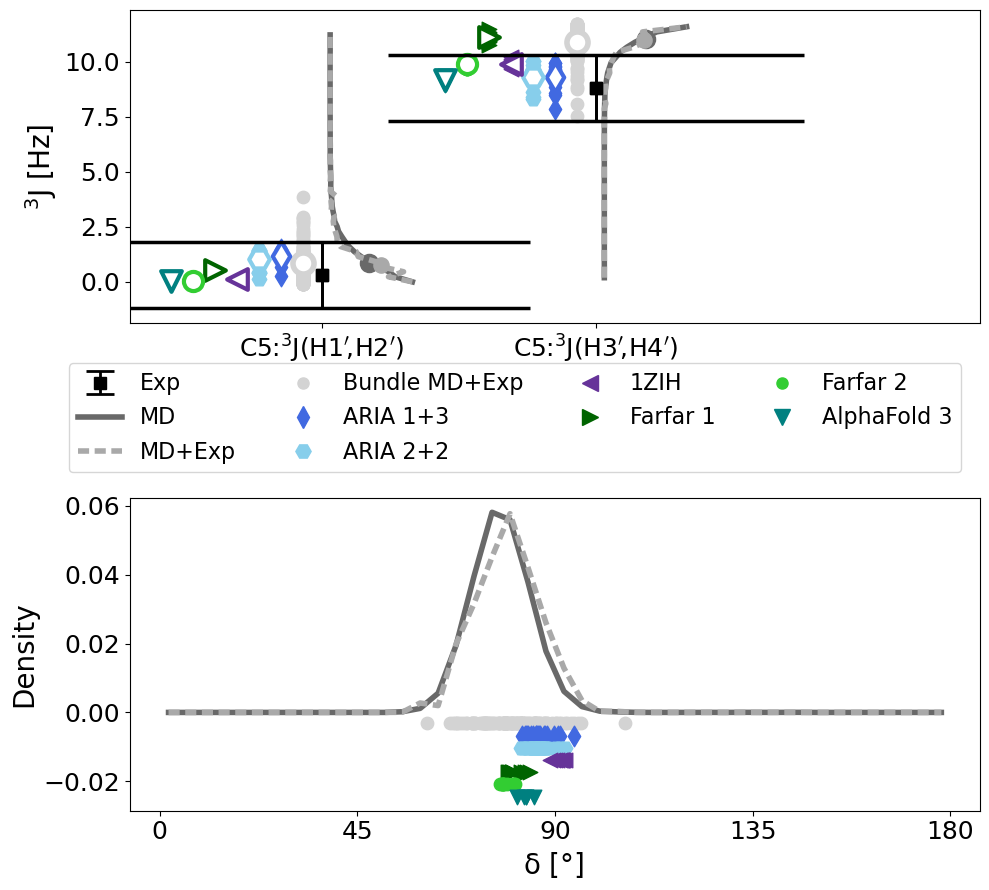

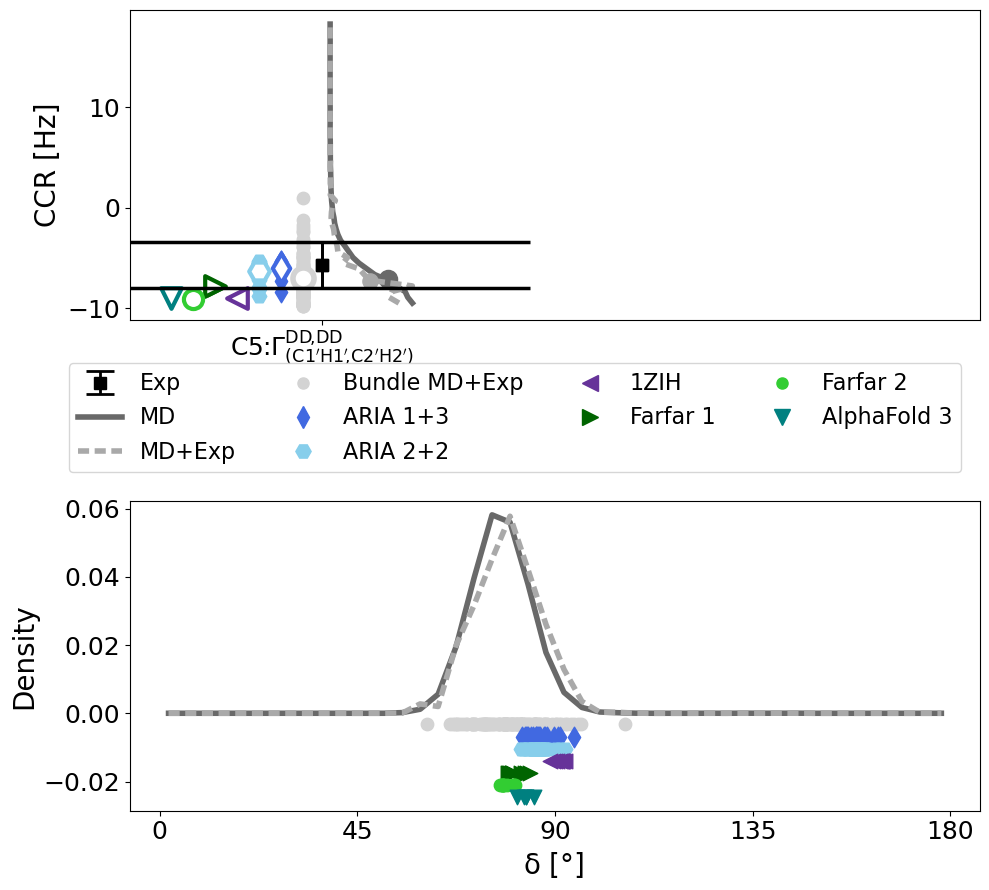

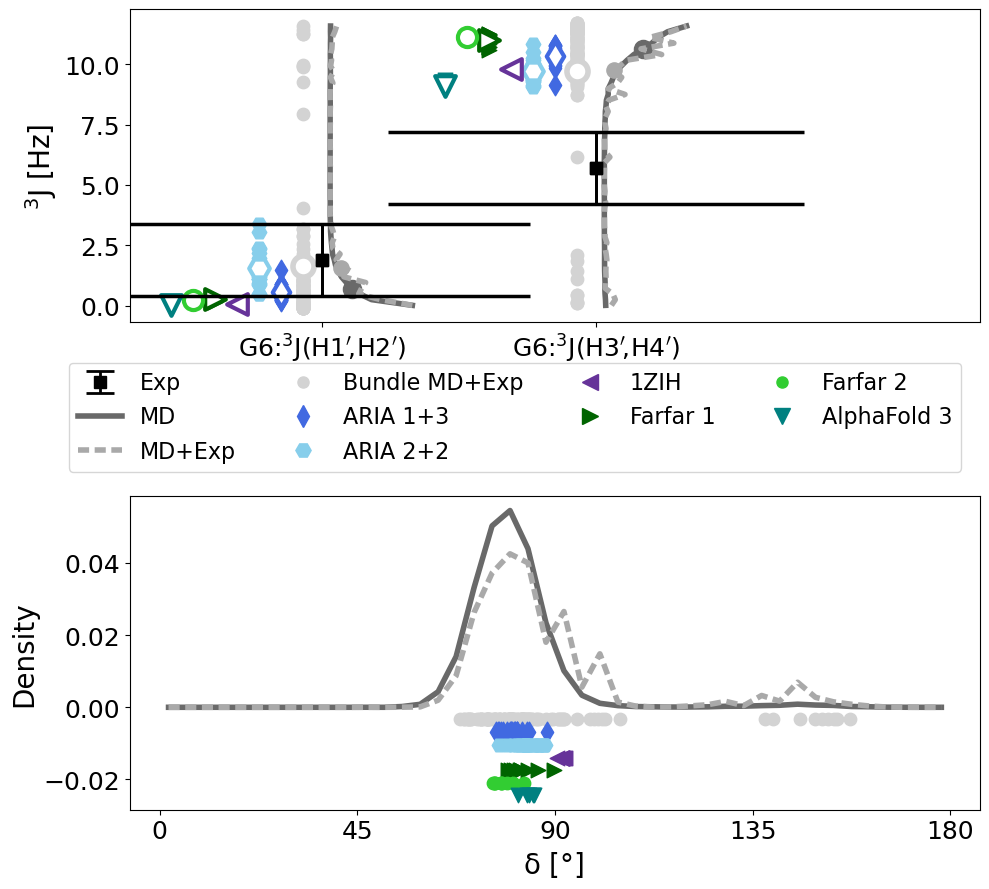

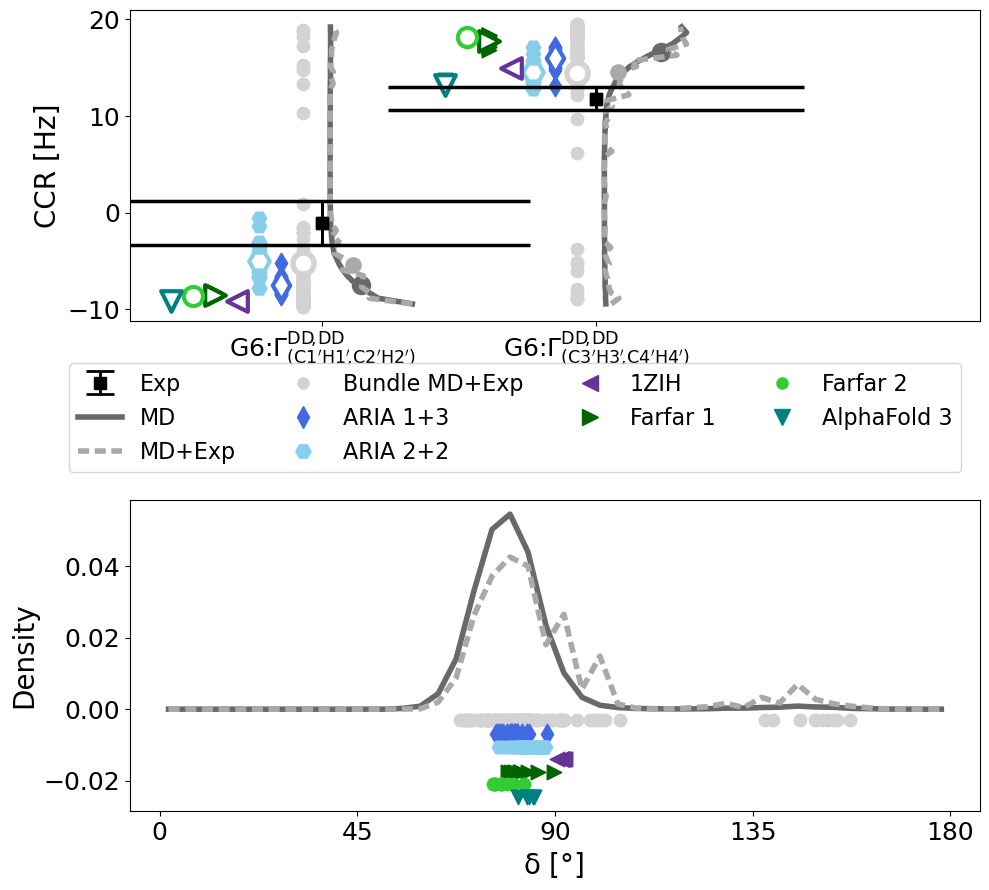

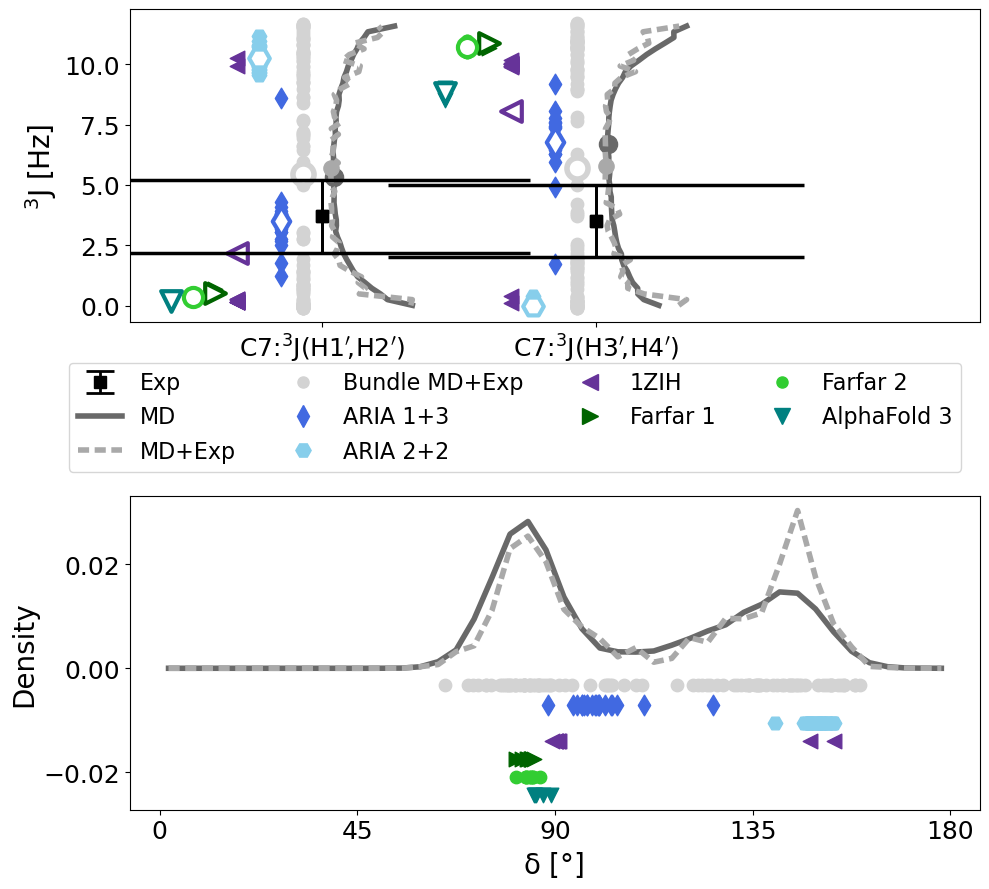

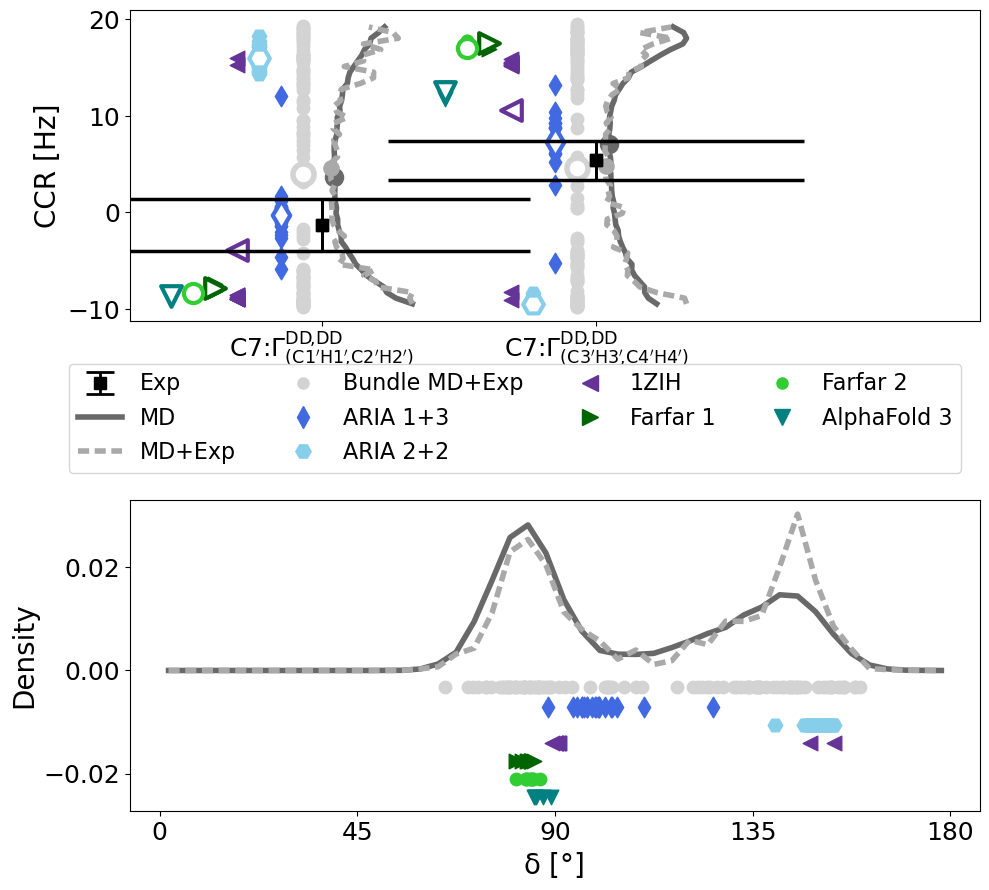

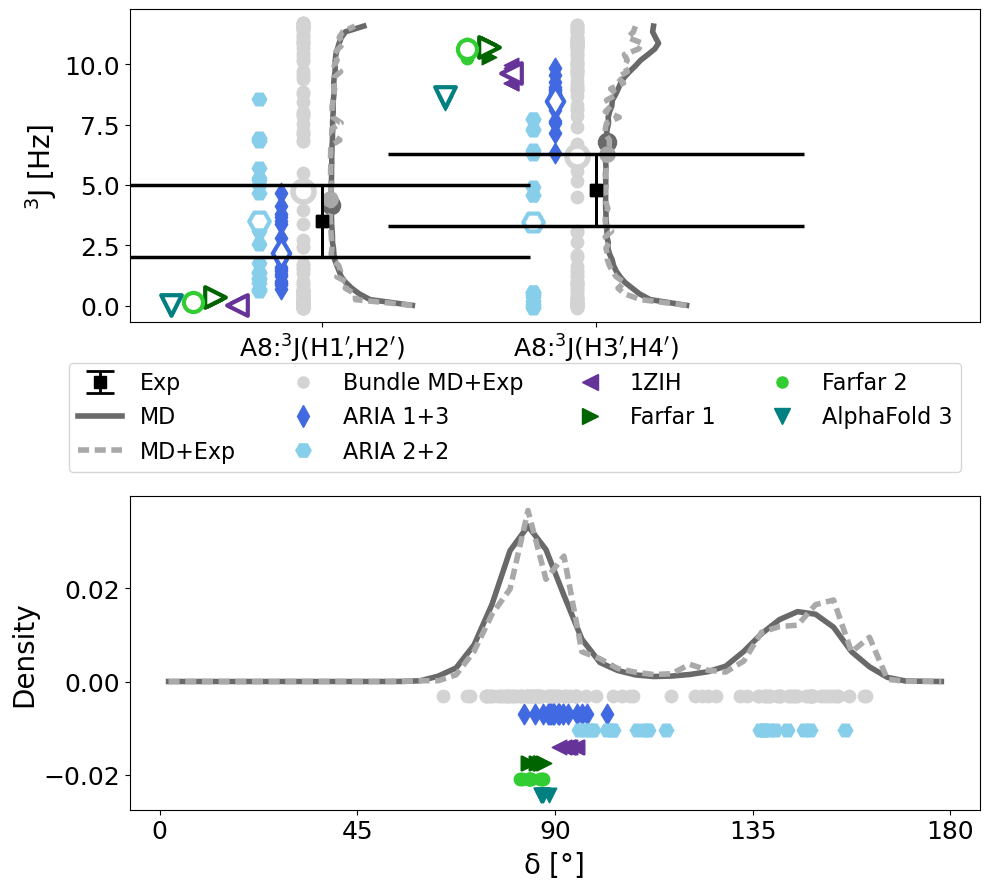

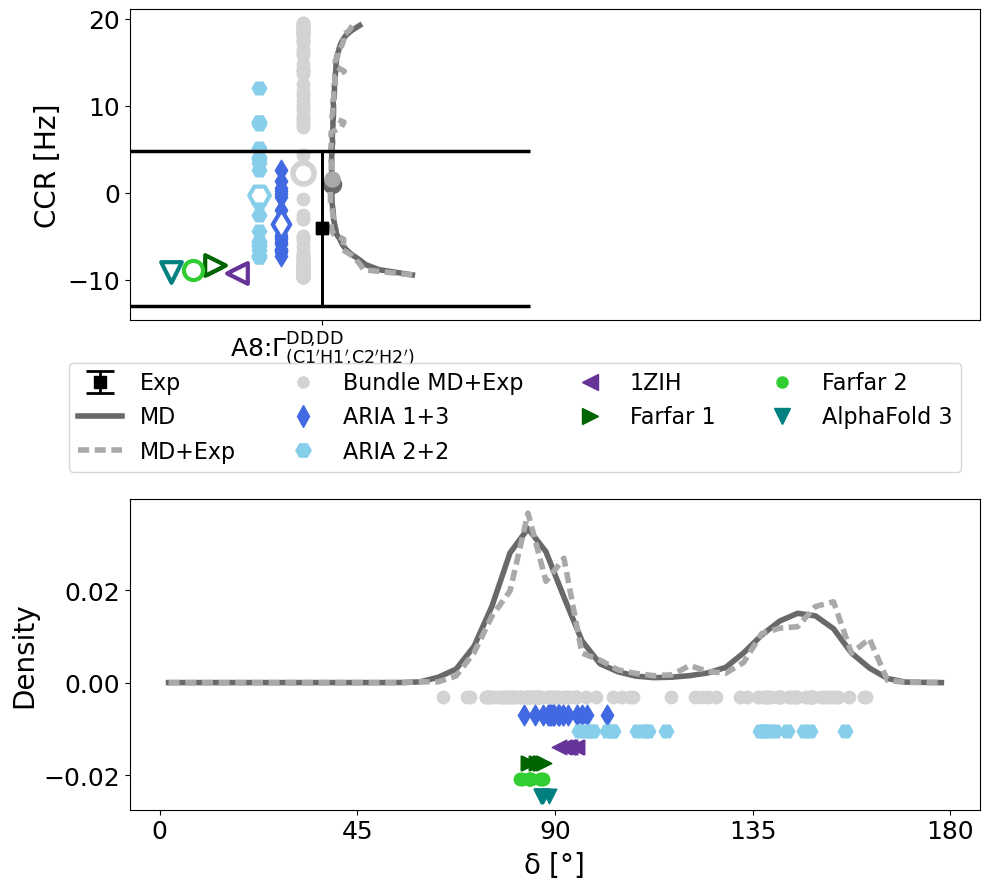

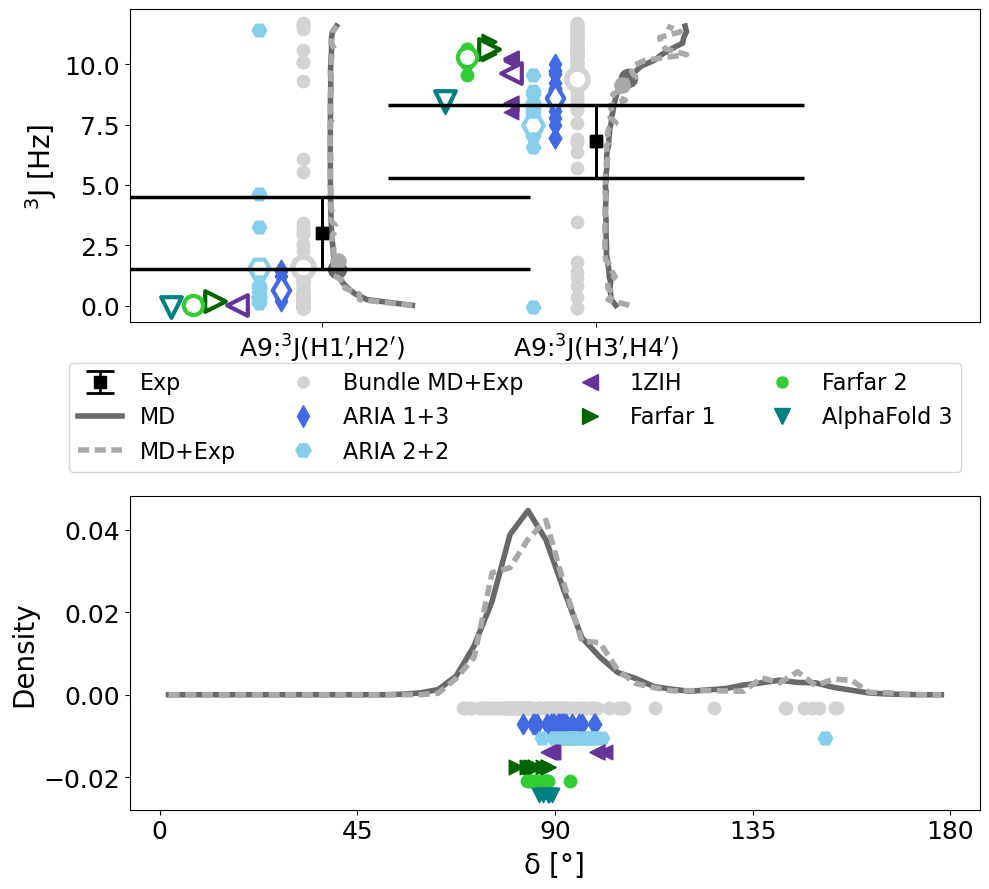

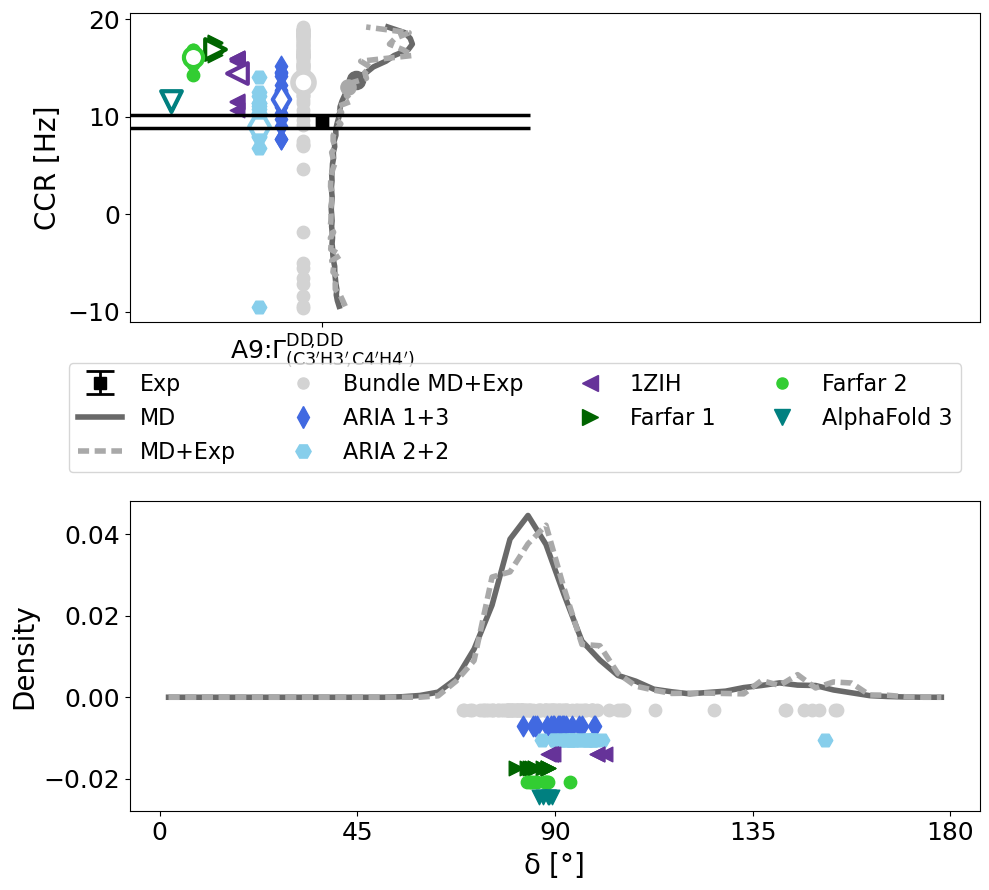

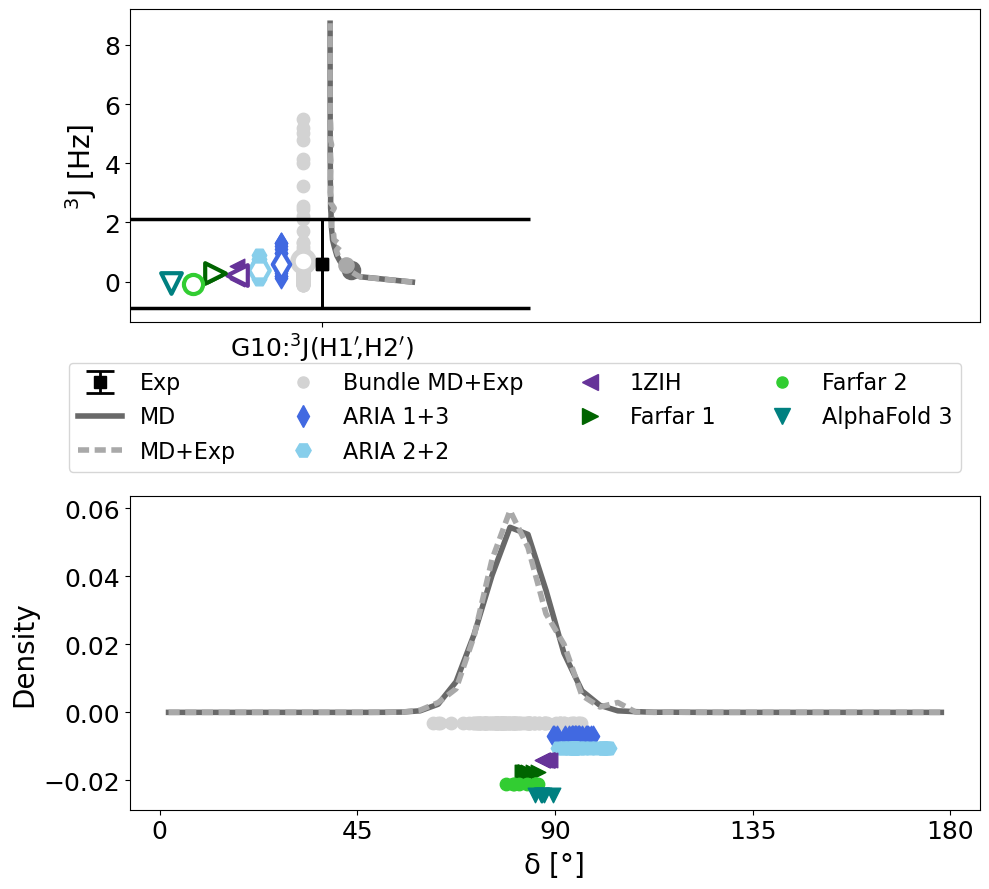

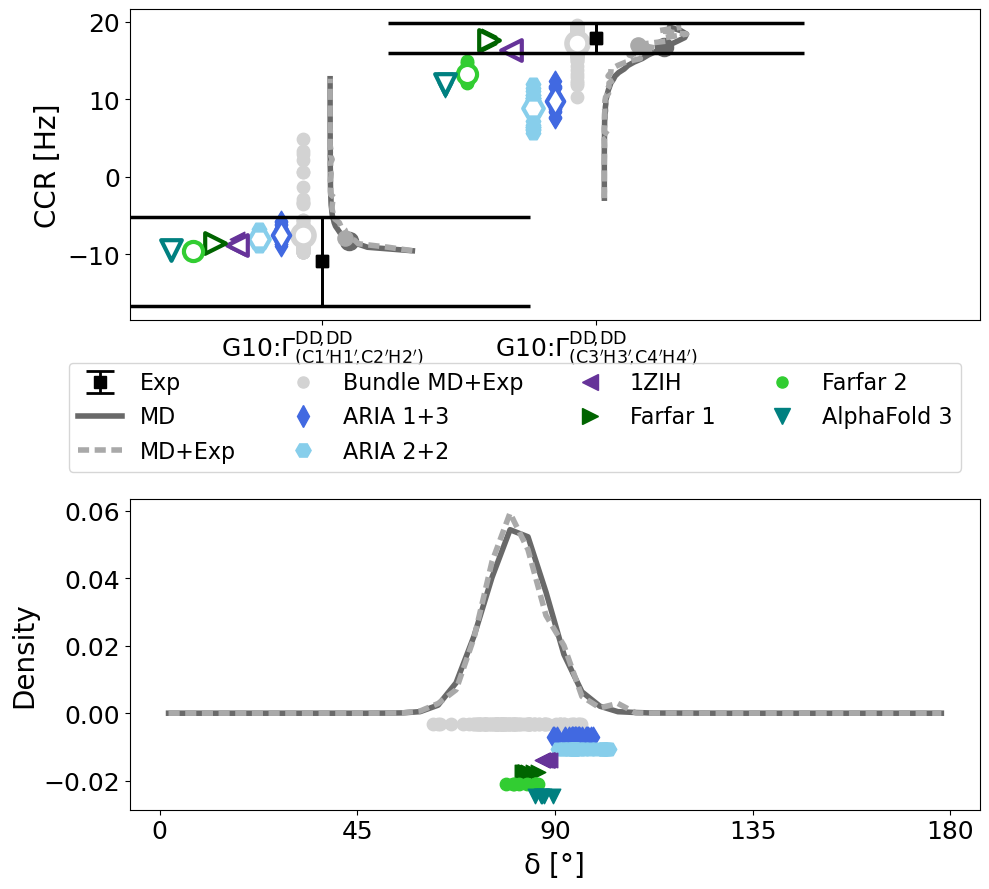

In [37]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'delta', ['H1H2', 'H2H3', 'H3H4'], 'j3', save=True)
    plot_angle_measurement_si(r, 'delta', ['C1-C2', 'C3-C4'], 'hcch', save=True)

## $\epsilon$

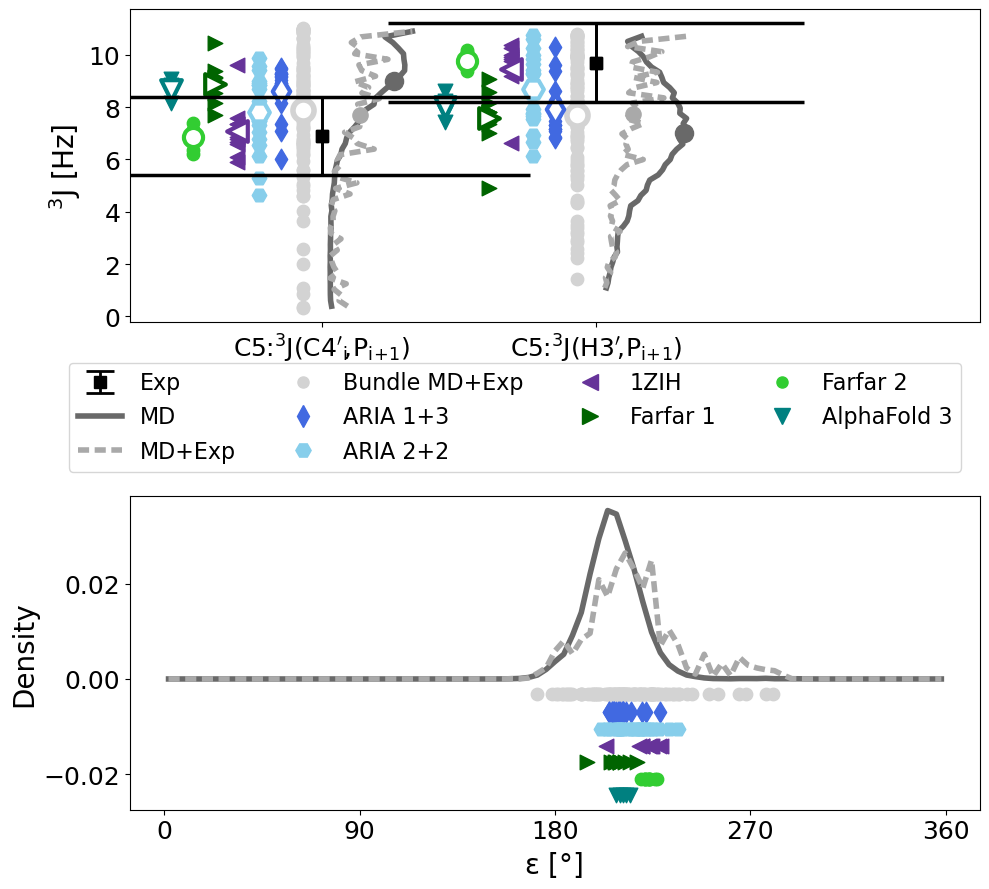

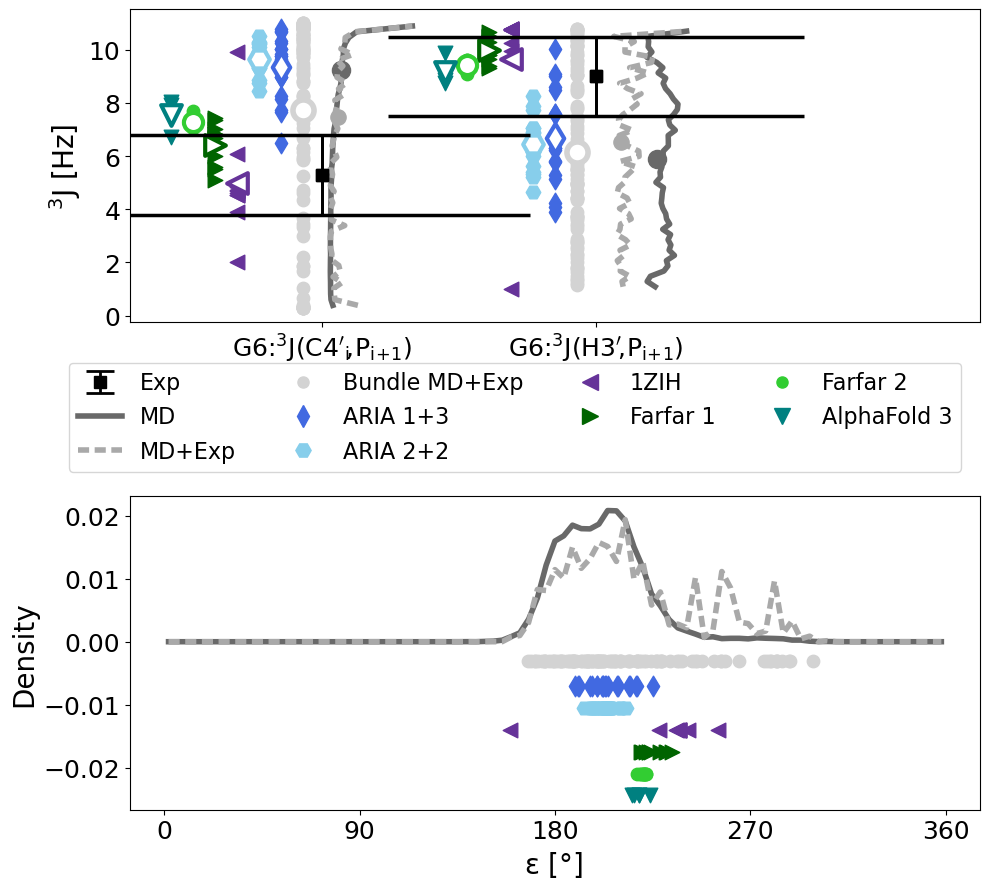

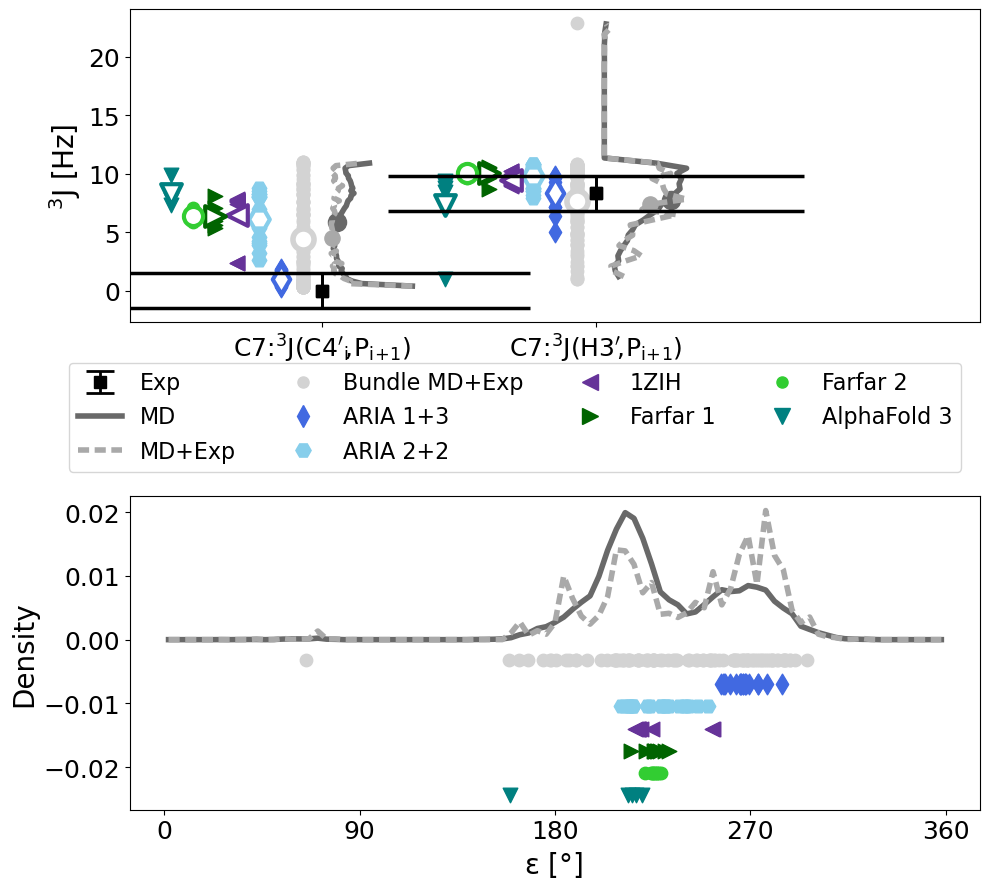

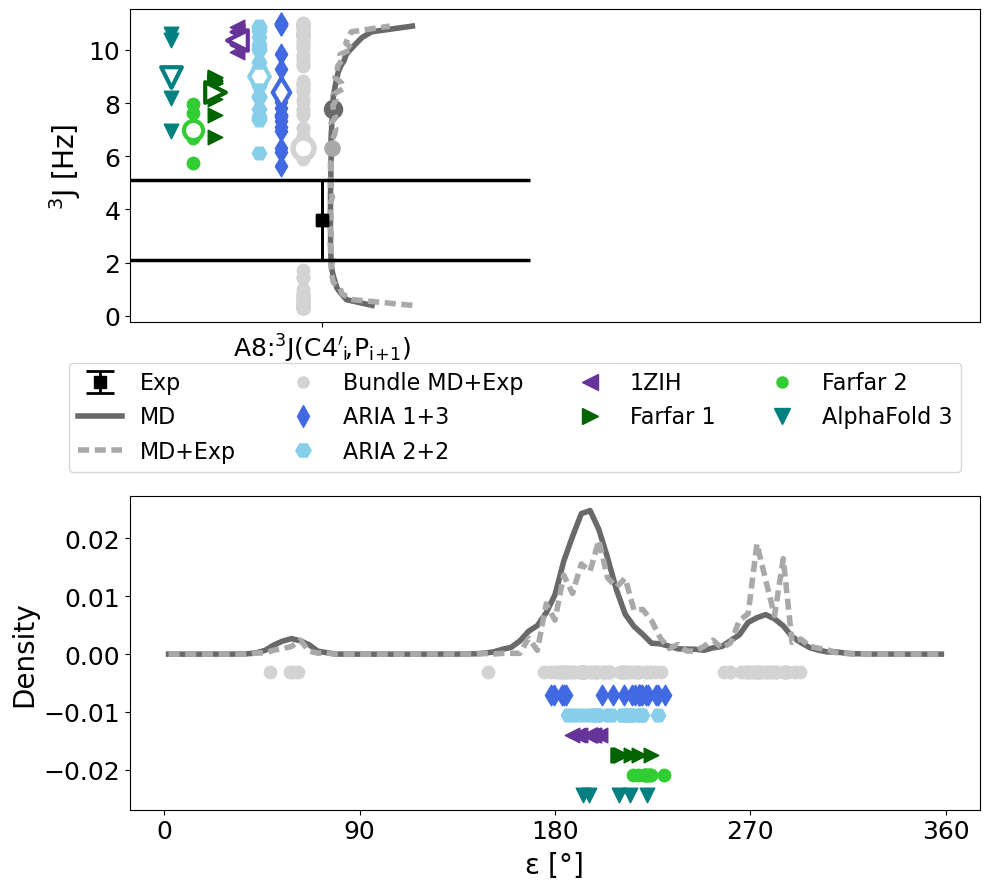

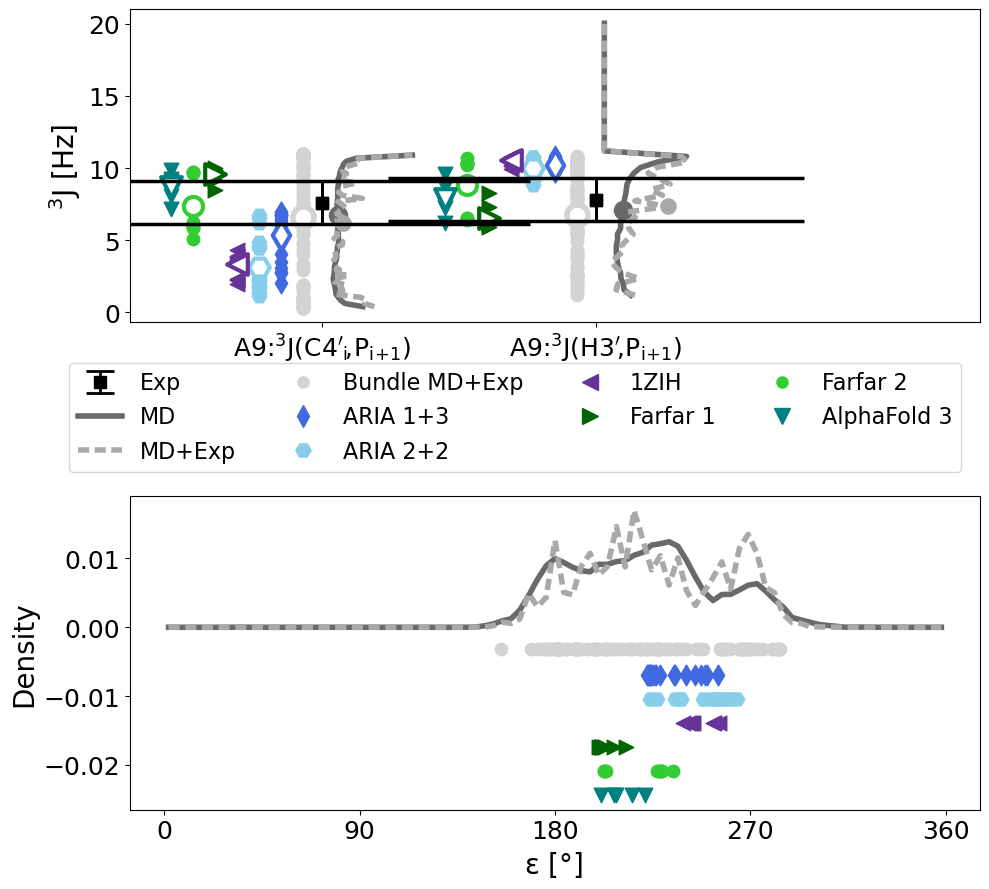

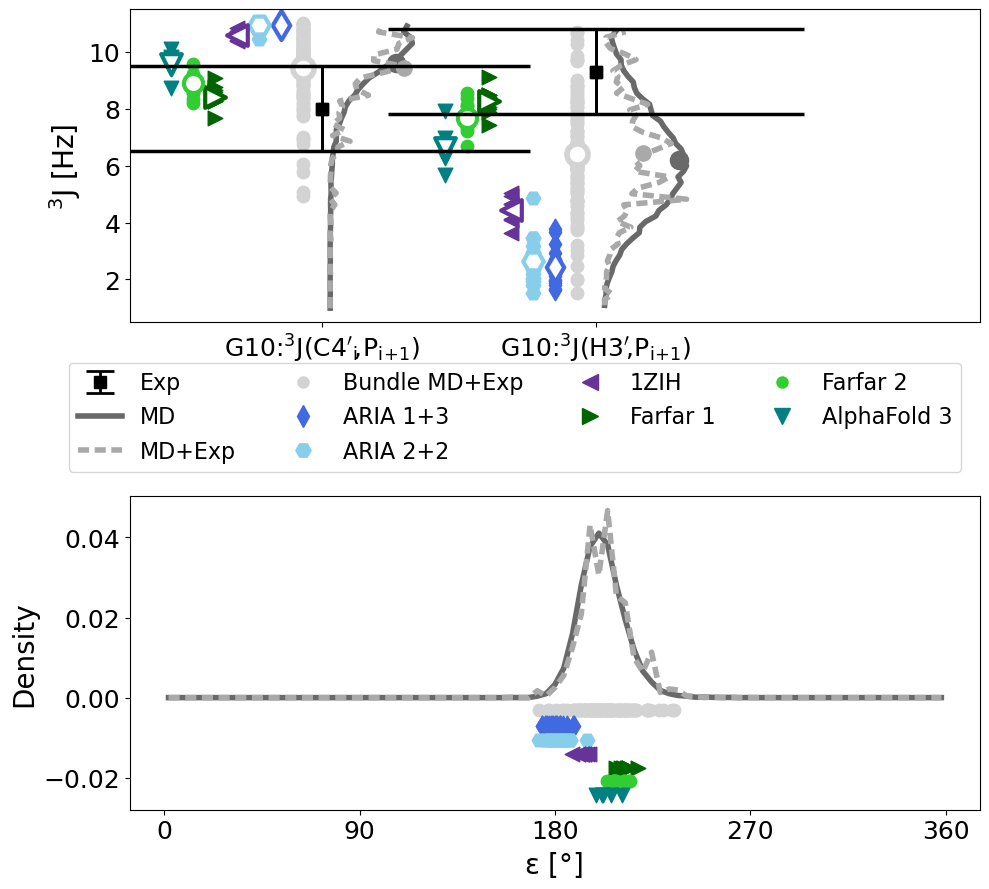

In [38]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'eps', ['C4Pe', 'H3P'], 'j3', save=True)

## $\zeta$

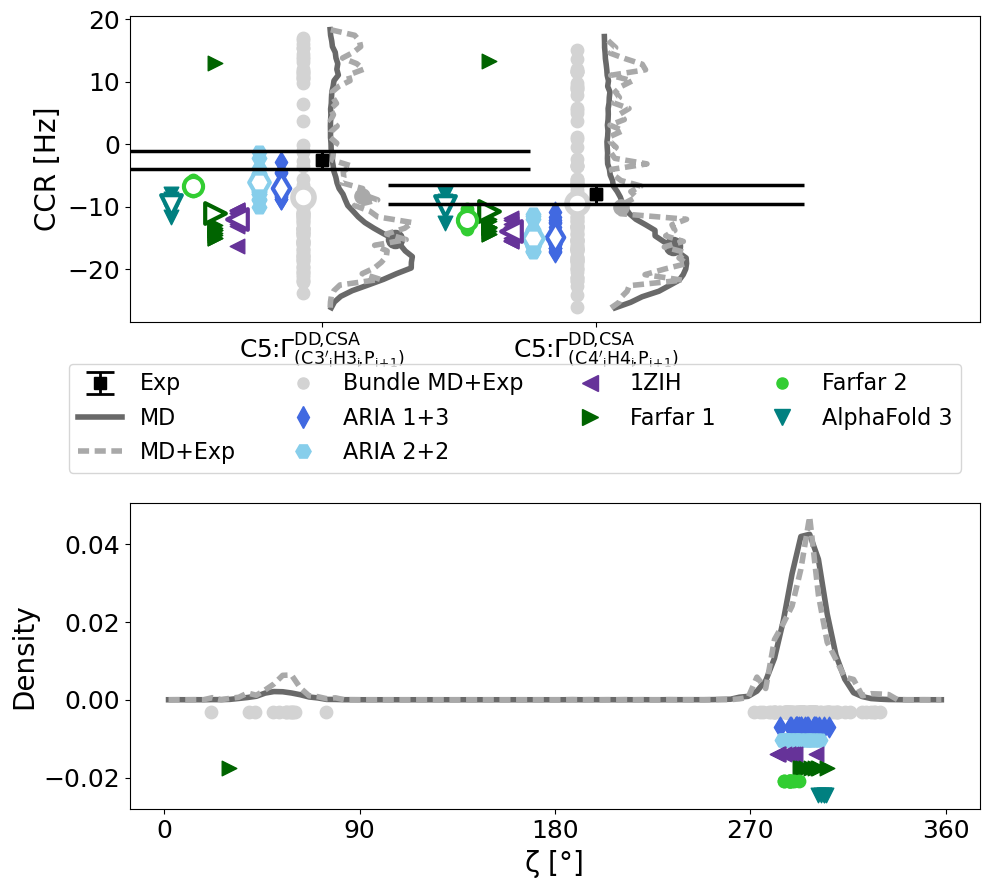

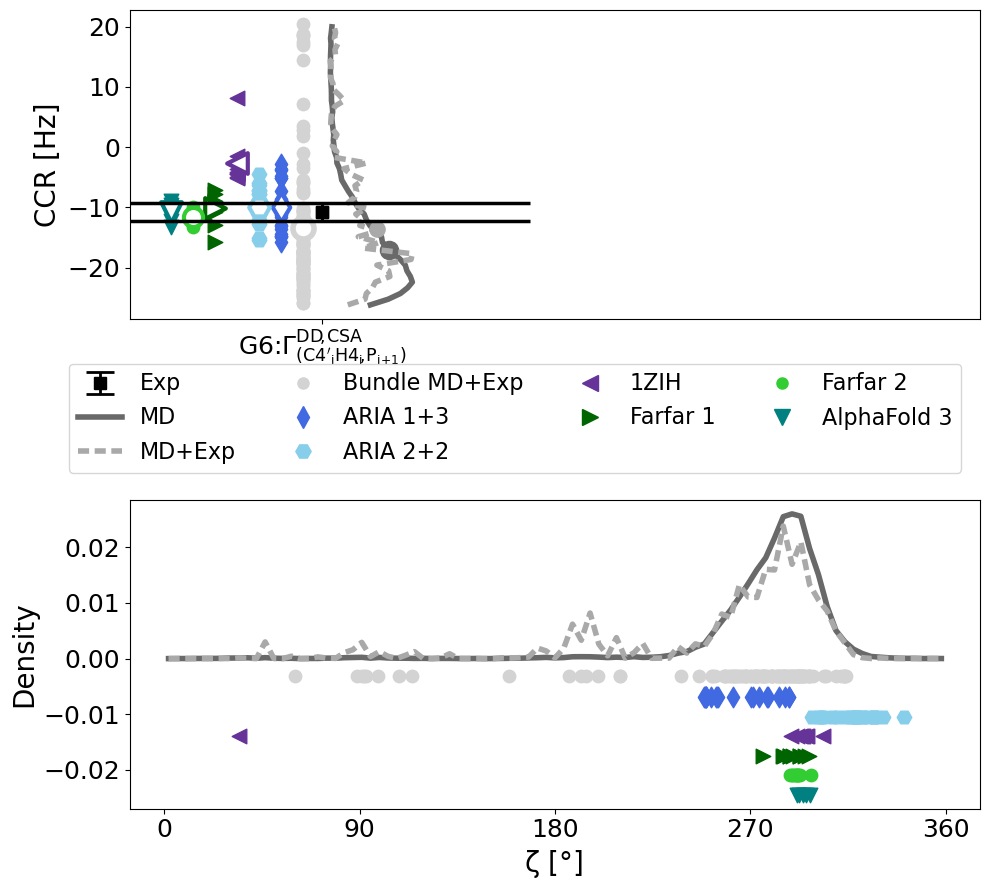

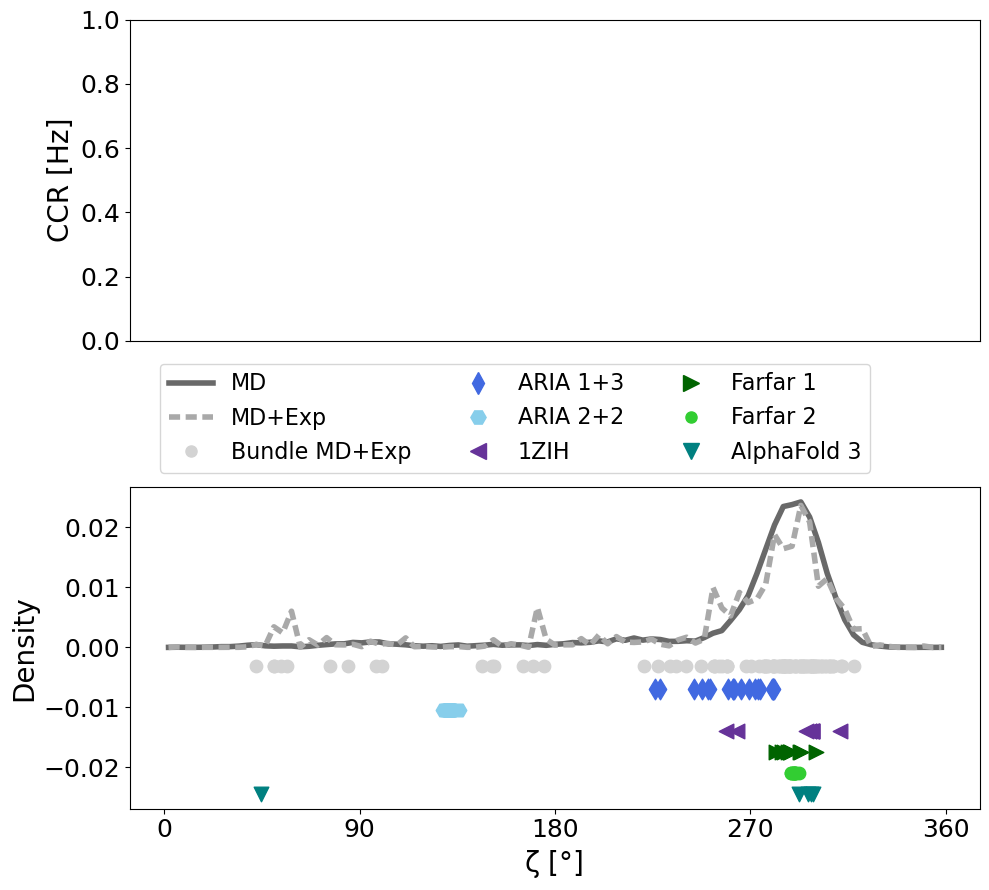

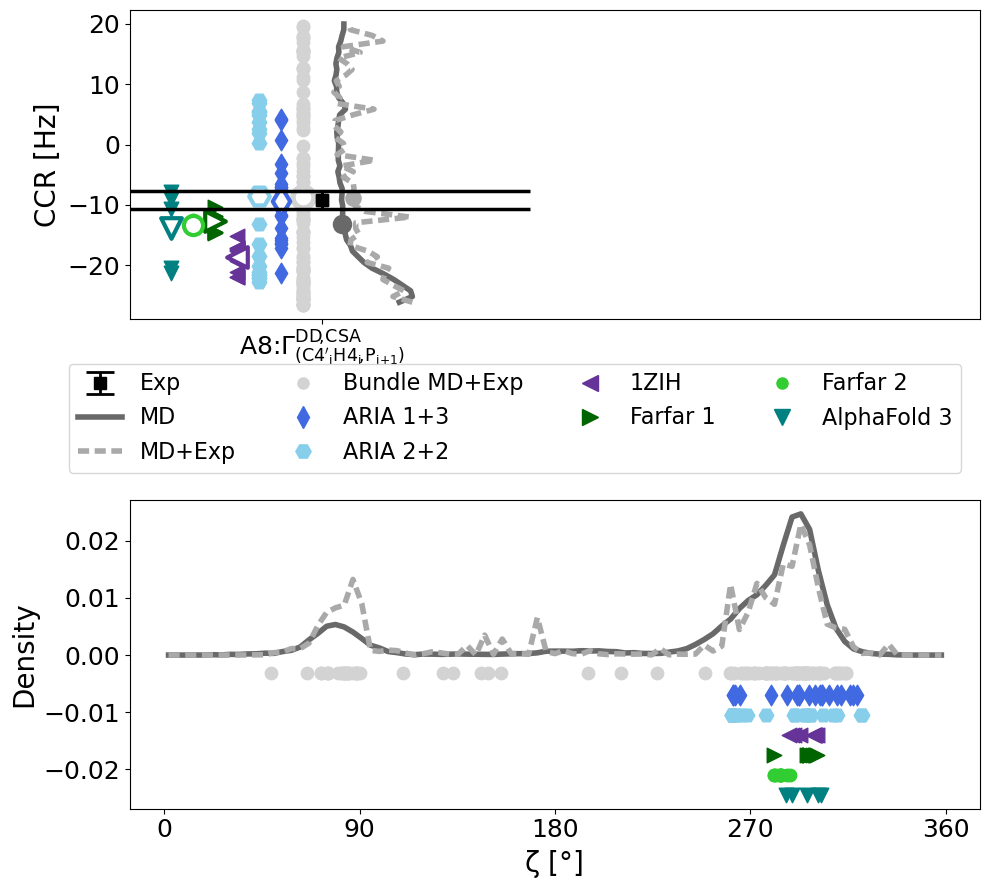

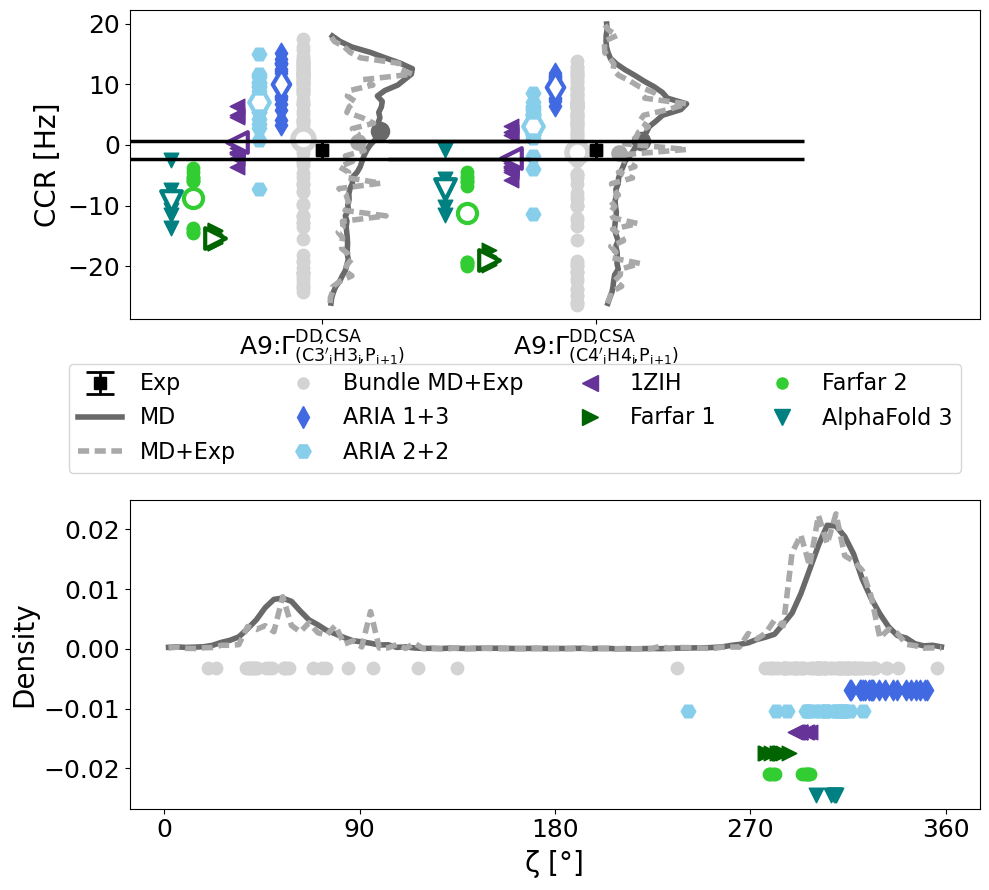

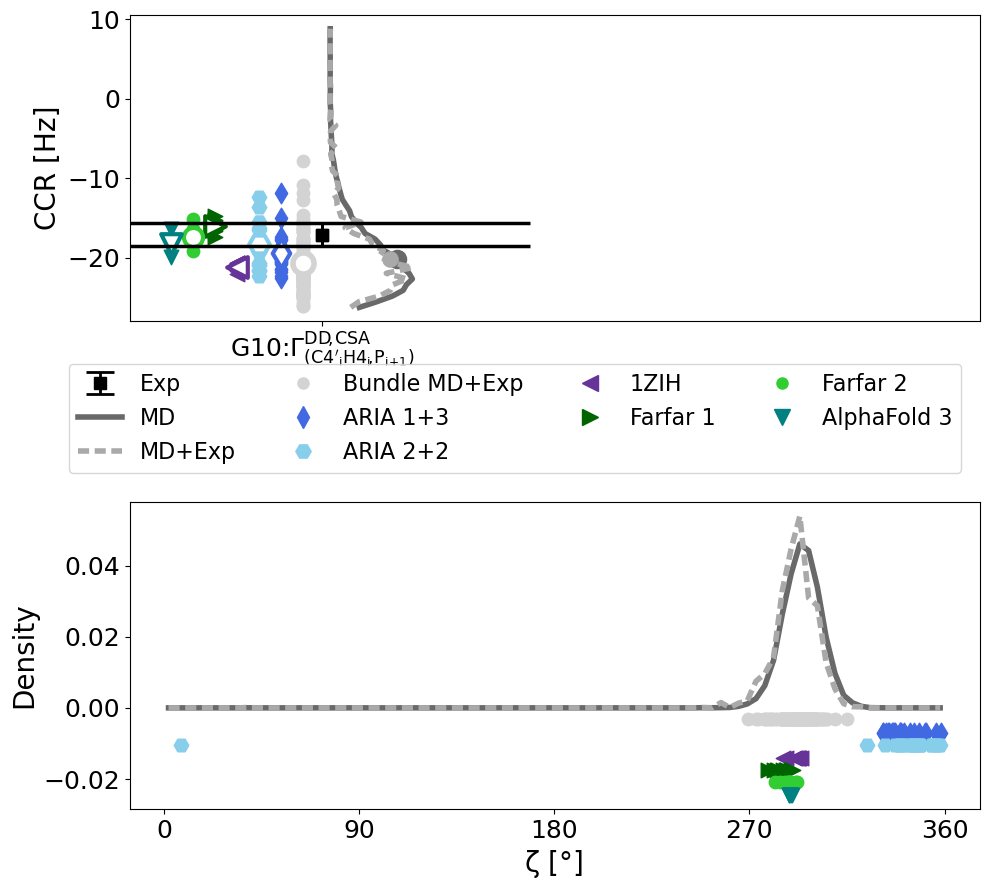

In [39]:
for i,r in enumerate(loop_res):
    plot_angle_measurement_si(r, 'zeta', ['C3p-P-plus', 'C4p-P-plus'], 'hcp', save=True)